In [1]:
"""
# Run this as a CLI script
jupyter nbconvert report_behavior_shs.ipynb --to python; python -u report_behavior_shs.py 
"""

# !pip install seaborn

'\n# Run this as a CLI script\njupyter nbconvert report_behavior_shs.ipynb --to python; python -u report_behavior_shs.py \n'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
import numpy as np
import sys
import argparse
import os
import glob
import utils_report as ru
import utils_behavior as ub
from utils_behavior import calculate_polarization, calculate_cohesion, theil_index
import cfg

# Check if we're in interactive mode or batch mode
batchmode = False
if "ipykernel_launcher" in sys.argv[0]:
    print("Interactive mode")
else:
    batchmode = True
    print("Batch/CLI mode")
    # Parses the command line arguments below


def get_latest_flat_pkl_file(input_dir="./"):
    pkl_files = glob.glob(input_dir + "/*.pkl")
    pkl_files = [f for f in pkl_files if "flat" in f]
    if not pkl_files:
        raise FileNotFoundError("No .pkl files found in the current directory.")
    latest_pkl_file = max(pkl_files, key=os.path.getctime)
    return latest_pkl_file

default_dir = "./results/rmappo-MultiAgentForagingEnv-check/"

outputs_folder = ru.get_latest_outputs_folder(default_dir)
    # "/srv/marl/satsingh/marl_fish/20241106_182038/outputs/"  # with biting
    # "/home/satsingh/srv/marl/satsingh/marl_fish/rmappo-MultiAgentFishEnv-114/outputs/"  # GOOD
    # "/home/satsingh/srv/marl/satsingh/marl_fish/20241013_202859/outputs"  # same as rmappo-MultiAgentFishEnv-114
    #     "/home/satsingh/srv/marl/satsingh/marl_fish/20241013_202859/outputs/" # BEST
    #     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202055/outputs/" # OK
    #     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202056/outputs/" # OK
    #     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202053/outputs/" # OK

if batchmode:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "outputs_folder",
        default=outputs_folder,
        nargs="?",
    )
    args = parser.parse_args()
    outputs_folder = args.outputs_folder

print(f"Using outputs folder: {outputs_folder}")

flat_pkl_file = get_latest_flat_pkl_file(outputs_folder)
print(f"Using .pkl file: {flat_pkl_file}")

dff = pd.read_pickle(flat_pkl_file)
# ru.print_column_shapes(dff)
print("dff.shape", dff.shape)
print("dff.columns", dff.columns)

/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/__init__.py:886: MatplotlibDeprecationWarning: 
examples.directory is deprecated; in the future, examples will be found relative to the 'datapath' directory.
  "found relative to the 'datapath' directory.".format(key))


Interactive mode
Using outputs folder: /home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs/
Using .pkl file: /home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs/MAZFish_neural_20250808_153214_bao_efp_0.05_vd_0.002_fd_10_agg_flattened.pkl
dff.shape (116000, 39)
dff.columns Index(['episode_index', 'time_step', 'agent_id', 'actions', 'observations',
       'rnn_states', 'rewards', 'attn_mask', 'env_id', 'position',
       'orientation', 'left_eye_angle', 'right_eye_angle', 'energy',
       'has_nearby', 'collided', 'detected_food_ids', 'eaten_food_ids',
       'cumulative_reward', 'food_positions', 'food_ids', 'arena_type',
       'arena_size', 'patch_kwargs.arena_size', 'patch_kwargs.arena_shape',
       'patch_kwargs.arena_radius', 'patch_kwargs.reset_food_density',
       'patch_kwargs.step_food_density', 'patch_

In [2]:
dff.drop(columns=["rnn_states"], inplace=True)

In [3]:
dff = dff.sort_values(
    by=["env_id", "episode_index", "agent_id", "time_step"]
).reset_index(drop=True)

print(dff.head())

   episode_index  time_step  agent_id                                actions  \
0              1          0         0  [-0.98870915, 0.43803963, 0.63978577]   
1              1          1         0  [-2.2243009, -0.06483698, -2.1473567]   
2              1          2         0   [0.87817544, -2.8888857, -1.4446247]   
3              1          3         0    [-2.7149925, -0.50928336, 1.762015]   
4              1          4         0       [5.683671, 2.4122388, -4.918922]   

                                        observations   rewards attn_mask  \
0  [0.4558359810969221, 0.7925043988465813, 0.0, ... -0.003078      None   
1  [0.4546557154607217, 0.7886861635804044, 0.0, ... -0.000721      None   
2  [0.4542643347067528, 0.7884616931821549, 0.0, ... -0.001010      None   
3  [0.4526703821650471, 0.7857694098121815, 0.0, ...  0.000299      None   
4  [0.44828372514431636, 0.7794692715501894, 0.0,... -0.003947      None   

   env_id                                 position  orientatio

Examining observations structure:
Type of observations in first row: <class 'numpy.ndarray'>
Shape of observations: (48,)
Sample observations (first 10 values): [ 0.    0.    0.    0.    0.    0.    0.    0.   -1.    0.33]
Min value: -1.229, Max value: 1.229
Observation shapes for first 10 rows: [(48,), (48,), (48,), (48,), (48,), (48,), (48,), (48,), (48,), (48,)]


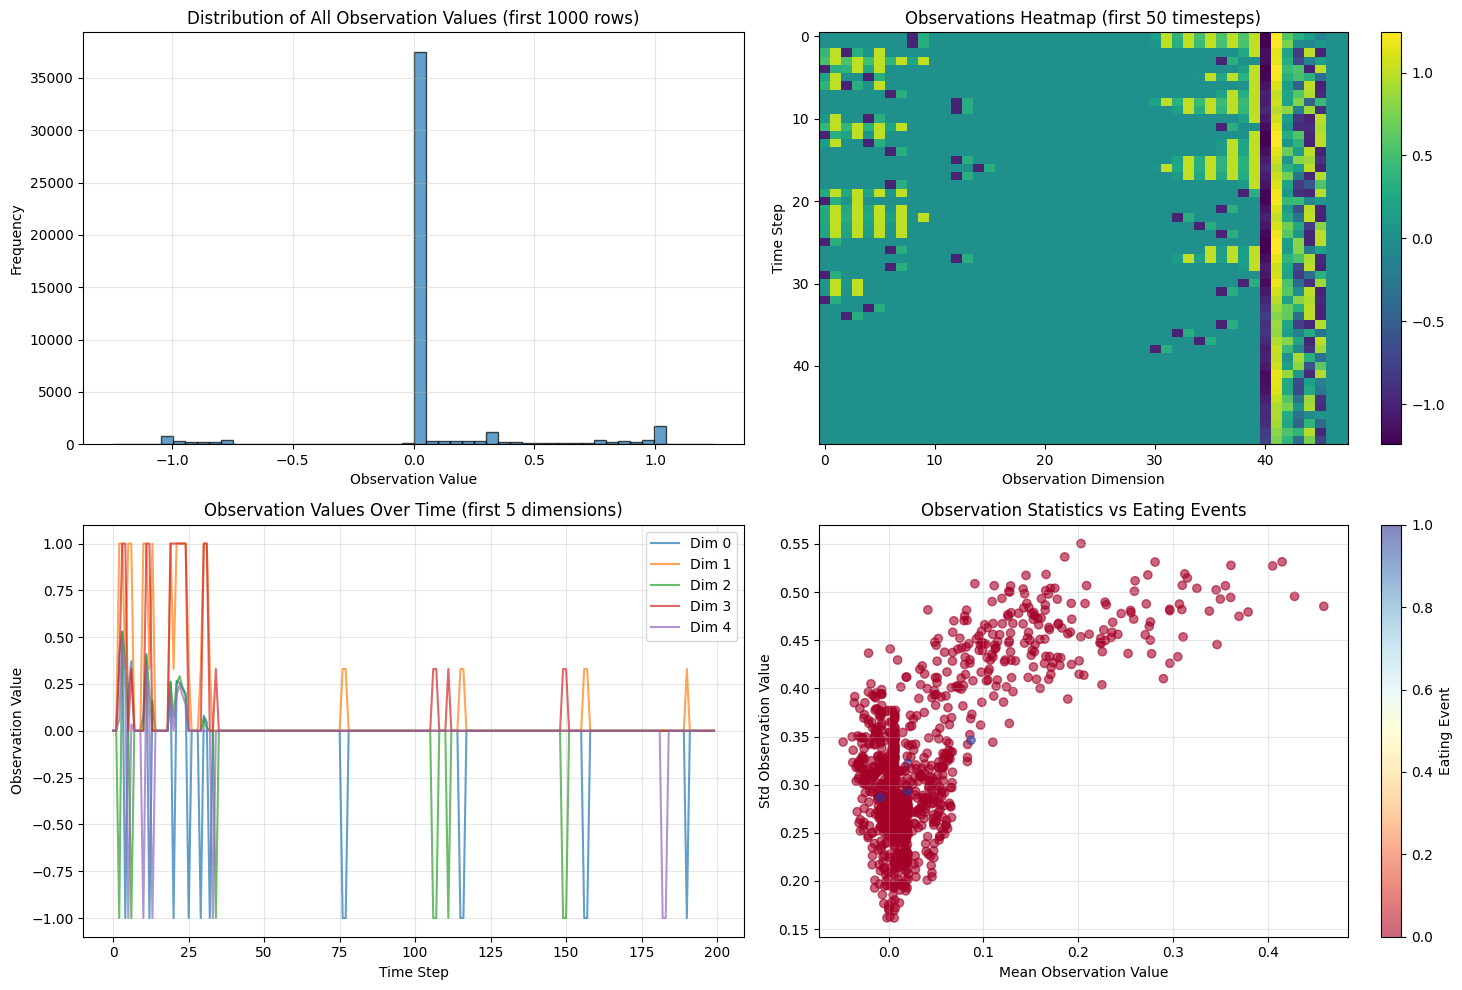


Observation Summary Statistics:
Observation vector length: 48
Mean observation value across all data: 0.045
Std observation value across all data: 0.345
Percentage of zero values: 77.5%

Eating vs Non-eating Observation Comparison:
Mean obs during eating: 0.097
Mean obs during non-eating: 0.032
Std obs during eating: 0.381
Std obs during non-eating: 0.337


In [53]:
# First, let's examine the structure of observations
print("Examining observations structure:")
print(f"Type of observations in first row: {type(dff.iloc[0]['observations'])}")
print(f"Shape of observations: {dff.iloc[0]['observations'].shape}")

# Look at a few sample observations
sample_obs = dff.iloc[0]['observations']
print(f"Sample observations (first 10 values): {sample_obs[:10]}")
print(f"Min value: {sample_obs.min():.3f}, Max value: {sample_obs.max():.3f}")

# Check if observations vary across rows
obs_shapes = [obs.shape for obs in dff['observations'].head(10)]
print(f"Observation shapes for first 10 rows: {obs_shapes}")

# Create debugging plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of observation values
all_obs = np.concatenate([obs.flatten() for obs in dff['observations'].head(1000)])
axes[0, 0].hist(all_obs, bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Observation Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of All Observation Values (first 1000 rows)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Observation heatmap for first few timesteps
obs_matrix = np.array([dff.iloc[i]['observations'] for i in range(min(50, len(dff)))])
im = axes[0, 1].imshow(obs_matrix, aspect='auto', cmap='viridis')
axes[0, 1].set_xlabel('Observation Dimension')
axes[0, 1].set_ylabel('Time Step')
axes[0, 1].set_title('Observations Heatmap (first 50 timesteps)')
plt.colorbar(im, ax=axes[0, 1])

# 3. Observation values over time for specific dimensions
time_steps = np.arange(min(200, len(dff)))
obs_subset = np.array([dff.iloc[i]['observations'] for i in time_steps])

# Plot first few dimensions
for dim in range(min(5, obs_subset.shape[1])):
    axes[1, 0].plot(time_steps, obs_subset[:, dim], alpha=0.7, label=f'Dim {dim}')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Observation Value')
axes[1, 0].set_title('Observation Values Over Time (first 5 dimensions)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Correlation between eating events and observation statistics
obs_means = [obs.mean() for obs in dff['observations'].head(1000)]
obs_stds = [obs.std() for obs in dff['observations'].head(1000)]
eating_events = dff['eating_event'].head(1000)

# Scatter plot colored by eating events
scatter = axes[1, 1].scatter(obs_means, obs_stds, 
                           c=eating_events, cmap='RdYlBu', alpha=0.6)
axes[1, 1].set_xlabel('Mean Observation Value')
axes[1, 1].set_ylabel('Std Observation Value')
axes[1, 1].set_title('Observation Statistics vs Eating Events')
plt.colorbar(scatter, ax=axes[1, 1], label='Eating Event')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nObservation Summary Statistics:")
print(f"Observation vector length: {dff.iloc[0]['observations'].shape[0]}")
print(f"Mean observation value across all data: {np.mean(all_obs):.3f}")
print(f"Std observation value across all data: {np.std(all_obs):.3f}")
print(f"Percentage of zero values: {(all_obs == 0).sum() / len(all_obs) * 100:.1f}%")

# Check for eating events and their observation patterns
eating_rows = dff[dff['eating_event'] == True]
if len(eating_rows) > 0:
    eating_obs = np.array([obs for obs in eating_rows['observations'].head(100)])
    non_eating_obs = np.array([obs for obs in dff[dff['eating_event'] == False]['observations'].head(100)])
    
    print(f"\nEating vs Non-eating Observation Comparison:")
    print(f"Mean obs during eating: {eating_obs.mean():.3f}")
    print(f"Mean obs during non-eating: {non_eating_obs.mean():.3f}")
    print(f"Std obs during eating: {eating_obs.std():.3f}")
    print(f"Std obs during non-eating: {non_eating_obs.std():.3f}")

Analyzing sensor observations:
Full observation length: 48
Sensor observations length: 40
Left eye sensor shape: (10, 2)
Right eye sensor shape: (10, 2)

Sample left eye sensors (distance, object_type):
[[ 0.    0.  ]
 [ 0.    0.  ]
 [ 0.    0.  ]
 [ 0.    0.  ]
 [-1.    0.33]
 [ 0.    0.  ]
 [ 0.    0.  ]
 [ 0.    0.  ]
 [ 0.    0.  ]
 [ 0.    0.  ]]

Sample right eye sensors (distance, object_type):
[[0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.16087417 1.        ]
 [0.37572661 1.        ]
 [0.50365144 1.        ]
 [0.55933708 1.        ]
 [0.56922933 1.        ]]

Extracting sensor data for all observations...
Extracted sensor data for 1000 observations


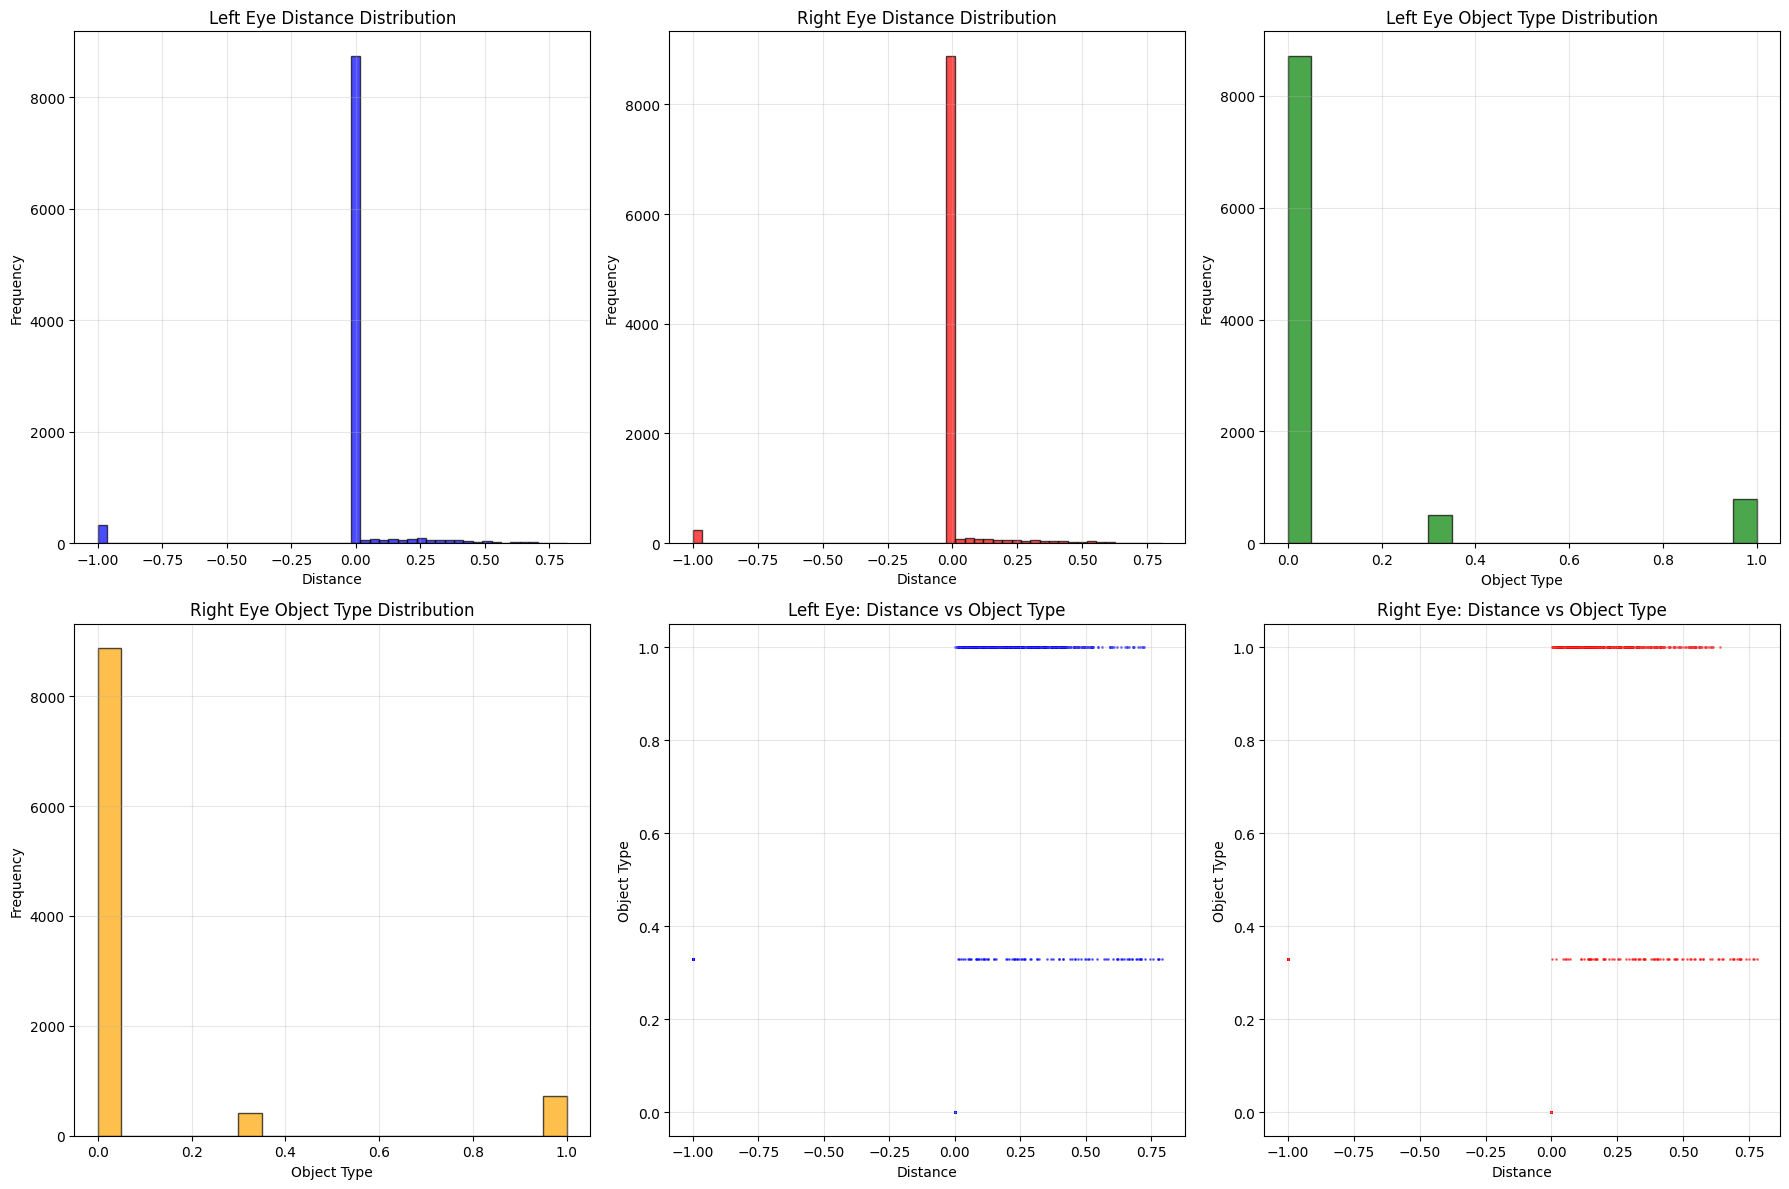


Sensor Data Summary Statistics:
Left eye distances - Mean: -0.004, Std: 0.208
Right eye distances - Mean: -0.000, Std: 0.180
Left eye object types - Unique values: [0.   0.33 1.  ]
Right eye object types - Unique values: [0.   0.33 1.  ]
Distance range: -1.000 to 0.818

Eating Events Sensor Analysis:
Number of eating event observations: 4
Eating - Left eye distances - Mean: 0.000
Eating - Right eye distances - Mean: 0.012
Non-eating - Left eye distances - Mean: -0.004
Non-eating - Right eye distances - Mean: -0.000


In [54]:
# Analyze sensor observations structure
print("Analyzing sensor observations:")
print(f"Full observation length: {dff.iloc[0]['observations'].shape[0]}")

# Extract sensor observations (first 40 elements)
sensor_obs_sample = dff.iloc[0]['observations'][:40]
print(f"Sensor observations length: {len(sensor_obs_sample)}")

# Split into left and right eye data
left_eye_sensors = sensor_obs_sample[:20].reshape(10, 2)  # 10 pairs of (distance, object_type)
right_eye_sensors = sensor_obs_sample[20:40].reshape(10, 2)  # 10 pairs of (distance, object_type)

print(f"Left eye sensor shape: {left_eye_sensors.shape}")
print(f"Right eye sensor shape: {right_eye_sensors.shape}")

print(f"\nSample left eye sensors (distance, object_type):")
print(left_eye_sensors)
print(f"\nSample right eye sensors (distance, object_type):")
print(right_eye_sensors)

# Create comprehensive sensor analysis
def extract_sensor_data(observations_array):
    """Extract and parse sensor observations from the full observations array"""
    sensor_obs = observations_array[:40]
    
    # Split into left and right eye data
    left_eye = sensor_obs[:20].reshape(10, 2)
    right_eye = sensor_obs[20:40].reshape(10, 2)
    
    return {
        'left_eye_distances': left_eye[:, 0],
        'left_eye_types': left_eye[:, 1],
        'right_eye_distances': right_eye[:, 0],
        'right_eye_types': right_eye[:, 1]
    }

# Extract sensor data for all observations
print("\nExtracting sensor data for all observations...")
sensor_data_list = []

for idx, row in dff.head(1000).iterrows():  # Start with first 1000 rows for efficiency
    sensor_data = extract_sensor_data(row['observations'])
    
    # Add metadata
    sensor_data.update({
        'row_idx': idx,
        'time_step': row['time_step'],
        'agent_id': row['agent_id'],
        'env_id': row['env_id'],
        'episode_index': row['episode_index'],
        'eating_event': row['eating_event']
    })
    
    sensor_data_list.append(sensor_data)

print(f"Extracted sensor data for {len(sensor_data_list)} observations")

# Analyze sensor data patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Sample sensor data for analysis
sample_data = sensor_data_list[0]

# 1. Distance distribution for left eye
all_left_distances = np.concatenate([data['left_eye_distances'] for data in sensor_data_list])
axes[0, 0].hist(all_left_distances, bins=50, alpha=0.7, edgecolor='black', color='blue')
axes[0, 0].set_xlabel('Distance')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Left Eye Distance Distribution')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distance distribution for right eye
all_right_distances = np.concatenate([data['right_eye_distances'] for data in sensor_data_list])
axes[0, 1].hist(all_right_distances, bins=50, alpha=0.7, edgecolor='black', color='red')
axes[0, 1].set_xlabel('Distance')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Right Eye Distance Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Object type distribution for left eye
all_left_types = np.concatenate([data['left_eye_types'] for data in sensor_data_list])
axes[0, 2].hist(all_left_types, bins=20, alpha=0.7, edgecolor='black', color='green')
axes[0, 2].set_xlabel('Object Type')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Left Eye Object Type Distribution')
axes[0, 2].grid(True, alpha=0.3)

# 4. Object type distribution for right eye
all_right_types = np.concatenate([data['right_eye_types'] for data in sensor_data_list])
axes[1, 0].hist(all_right_types, bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[1, 0].set_xlabel('Object Type')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Right Eye Object Type Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 5. Distance vs Object Type scatter plot (left eye)
sample_indices = np.random.choice(len(all_left_distances), size=min(5000, len(all_left_distances)), replace=False)
axes[1, 1].scatter(all_left_distances[sample_indices], all_left_types[sample_indices], 
                   alpha=0.5, s=1, color='blue')
axes[1, 1].set_xlabel('Distance')
axes[1, 1].set_ylabel('Object Type')
axes[1, 1].set_title('Left Eye: Distance vs Object Type')
axes[1, 1].grid(True, alpha=0.3)

# 6. Distance vs Object Type scatter plot (right eye)
axes[1, 2].scatter(all_right_distances[sample_indices], all_right_types[sample_indices], 
                   alpha=0.5, s=1, color='red')
axes[1, 2].set_xlabel('Distance')
axes[1, 2].set_ylabel('Object Type')
axes[1, 2].set_title('Right Eye: Distance vs Object Type')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/sensor_observations_analysis.png", dpi=300)
plt.show()

# Print summary statistics
print(f"\nSensor Data Summary Statistics:")
print(f"Left eye distances - Mean: {np.mean(all_left_distances):.3f}, Std: {np.std(all_left_distances):.3f}")
print(f"Right eye distances - Mean: {np.mean(all_right_distances):.3f}, Std: {np.std(all_right_distances):.3f}")
print(f"Left eye object types - Unique values: {np.unique(all_left_types)}")
print(f"Right eye object types - Unique values: {np.unique(all_right_types)}")
print(f"Distance range: {np.min(np.concatenate([all_left_distances, all_right_distances])):.3f} to {np.max(np.concatenate([all_left_distances, all_right_distances])):.3f}")

# Analyze sensor data during eating events
eating_sensor_data = [data for data in sensor_data_list if data['eating_event']]
non_eating_sensor_data = [data for data in sensor_data_list if not data['eating_event']]

if len(eating_sensor_data) > 0:
    print(f"\nEating Events Sensor Analysis:")
    print(f"Number of eating event observations: {len(eating_sensor_data)}")
    
    eating_left_distances = np.concatenate([data['left_eye_distances'] for data in eating_sensor_data])
    eating_right_distances = np.concatenate([data['right_eye_distances'] for data in eating_sensor_data])
    
    print(f"Eating - Left eye distances - Mean: {np.mean(eating_left_distances):.3f}")
    print(f"Eating - Right eye distances - Mean: {np.mean(eating_right_distances):.3f}")
    
    non_eating_left_distances = np.concatenate([data['left_eye_distances'] for data in non_eating_sensor_data])
    non_eating_right_distances = np.concatenate([data['right_eye_distances'] for data in non_eating_sensor_data])
    
    print(f"Non-eating - Left eye distances - Mean: {np.mean(non_eating_left_distances):.3f}")
    print(f"Non-eating - Right eye distances - Mean: {np.mean(non_eating_right_distances):.3f}")

In [4]:
dff["move_forward"]

0         0.438040
1        -0.064837
2        -2.888886
3        -0.509283
4         2.412239
            ...   
115995   -1.280035
115996   -1.247510
115997   -3.984282
115998   -0.111488
115999    1.462690
Name: move_forward, Length: 116000, dtype: float64

In [ ]:
# dff["move_forward"] = dff["move_forward"] * cfg.FISH_CONSTANTS["max_speed"]
# dff["turn_angle"] = dff["turn_angle"] * cfg.FISH_CONSTANTS["max_turn_speed"]

# # Compute vergence angle and speed
# perception_field = 163 * np.pi / 180
# dff['vergence_angle'] = dff['left_eye_angle'] - dff['right_eye_angle'] + perception_field
# dff['speed'] = dff['displacement'] * cfg.ENV_PARAMS["fps_sim"]

In [6]:
import os

# Create a figure results folder
results_folder = f"{outputs_folder}/figures"
os.makedirs(results_folder, exist_ok=True)

print(f"Created folder: {results_folder}")

Created folder: /home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/20250807_182311_1_bao_efp_0.05_vd_0.002_fd_10/outputs//figures


In [ ]:
# # Speed is calculated via displacement so has some bugs -- more interesting to look at move_forward

# dff['speed'] = dff['move_forward']

In [8]:
num_eating_events = dff['eating_event'].sum()
num_episodes = dff.drop_duplicates(['env_id', 'episode_index']).shape[0]
eating_events_per_episode = num_eating_events / num_episodes

# Compute average total episode reward (reward at last step of each episode)
episode_rewards = dff.groupby(['env_id', 'episode_index'])['cumulative_reward'].last()
avg_total_episode_reward = episode_rewards.mean()
print(f"Average total episode reward: {avg_total_episode_reward:.2f}")

with open(os.path.join(results_folder, "performance_metrics.txt"), "w") as f:
    f.write(f"Total eating events: {num_eating_events}\n")
    f.write(f"Total episodes: {num_episodes}\n")
    f.write(f"Average total episode reward: {avg_total_episode_reward:.2f}\n")
    f.write(f"Eating events per episode: {eating_events_per_episode:.2f}\n")

Average total episode reward: 31.08


In [11]:
# Filter observations just before the first eating event
first_eating_index = dff[dff['eating_event']].index.min()
if first_eating_index > 0:
    pre_first_eating_observations = dff.loc[first_eating_index - 1, 'observations']
    print("Observations just before the first eating event:")
    print(pre_first_eating_observations)
else:
    print("No eating events found or no observations before the first eating event.")


Observations just before the first eating event:
[ 0.55738152  0.59462971  0.          0.          0.79372075  0.
  0.          0.          0.         -1.          0.33        0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.99501524  0.00487499  0.80400068
 -0.80400068 -0.82124943  0.82124943]


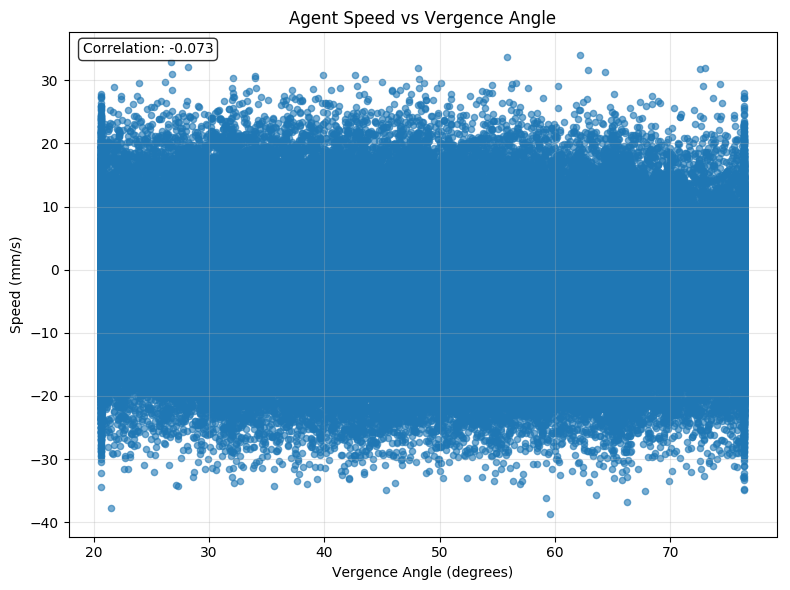

Correlation between vergence angle and speed: -0.0726


In [8]:
# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dff['vergence_angle']*180/np.pi, dff['speed'], alpha=0.6, s=20)
plt.xlabel('Vergence Angle (degrees)')
plt.ylabel('Speed (mm/s)')
plt.title('Agent Speed vs Vergence Angle')
plt.grid(True, alpha=0.3)

# Add correlation coefficient
correlation = np.corrcoef(dff['vergence_angle'], dff['speed'])[0, 1]
plt.text(0.02, 0.98, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{results_folder}/agent_speed_vs_vergence_angle.png", dpi=300)
plt.show()

print(f"Correlation between vergence angle and speed: {correlation:.4f}")

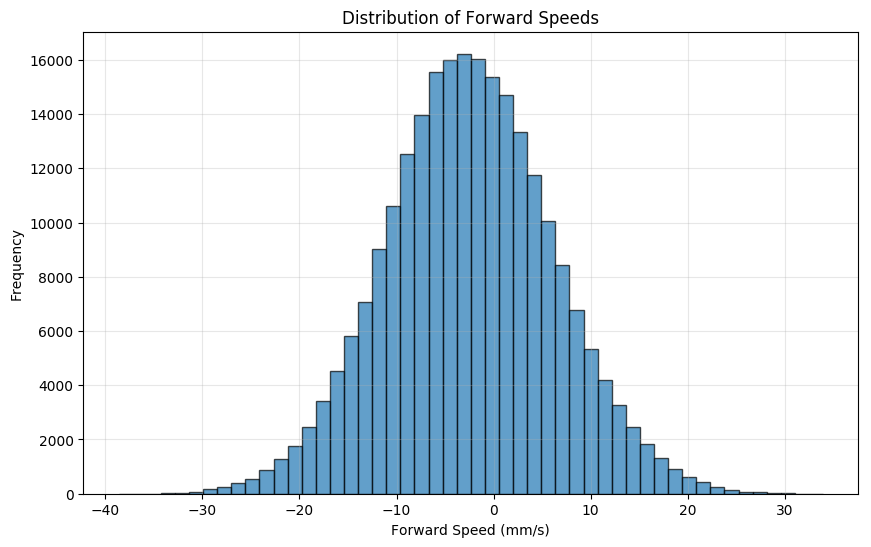

Mean move_forward: -2.481
Standard deviation: 8.646
Min move_forward: -38.650
Max move_forward: 33.951


In [9]:
plt.figure(figsize=(10, 6))
plt.hist(dff['move_forward'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Forward Speed (mm/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Forward Speeds')
plt.grid(True, alpha=0.3)
plt.savefig(f"{results_folder}/move_forward_distribution.png", dpi=300)
plt.show()
    
# Print some basic statistics
print(f"Mean move_forward: {dff['move_forward'].mean():.3f}")
print(f"Standard deviation: {dff['move_forward'].std():.3f}")
print(f"Min move_forward: {dff['move_forward'].min():.3f}")
print(f"Max move_forward: {dff['move_forward'].max():.3f}")

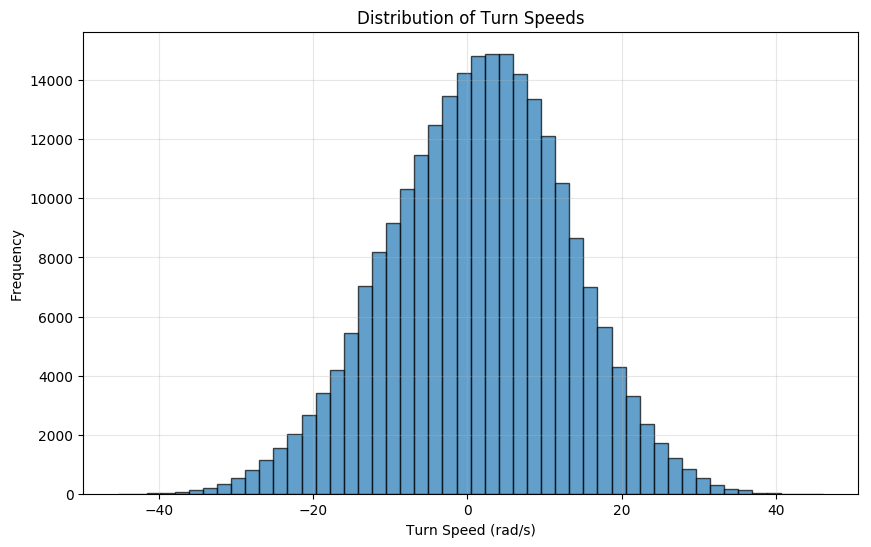

Mean turn_angle: 1.365
Standard deviation: 11.606
Min turn_angle: -45.322
Max turn_angle: 46.148


In [10]:
plt.figure(figsize=(10, 6))
plt.hist(dff['turn_angle'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Turn Speed (rad/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Turn Speeds')
plt.grid(True, alpha=0.3)
plt.savefig(f"{results_folder}/turn_angle_distribution.png", dpi=300)
plt.show()

# Print some basic statistics
print(f"Mean turn_angle: {dff['turn_angle'].mean():.3f}")
print(f"Standard deviation: {dff['turn_angle'].std():.3f}")
print(f"Min turn_angle: {dff['turn_angle'].min():.3f}")
print(f"Max turn_angle: {dff['turn_angle'].max():.3f}")

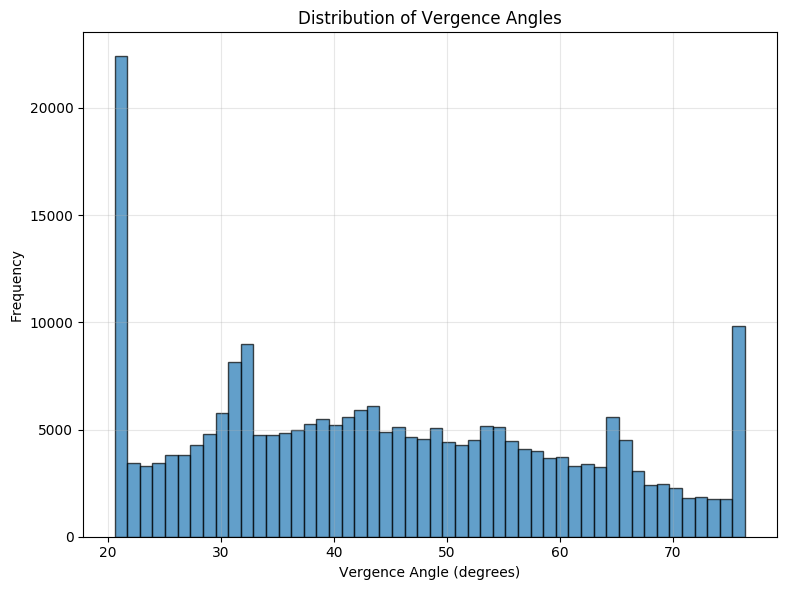

Mean vergence angle: 44.59 degrees
Standard deviation: 16.21 degrees
Min vergence angle: 20.60 degrees
Max vergence angle: 76.40 degrees


In [11]:
# Convert vergence angle from radians to degrees for analysis
dff['vergence_angle_deg'] = dff['vergence_angle'] * 180 / np.pi

plt.figure(figsize=(8, 6))
plt.hist(dff['vergence_angle_deg'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Vergence Angle (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Vergence Angles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_folder}/vergence_angle_distribution.png", dpi=300)
plt.show()

# Print some basic statistics in degrees
print(f"Mean vergence angle: {dff['vergence_angle_deg'].mean():.2f} degrees")
print(f"Standard deviation: {dff['vergence_angle_deg'].std():.2f} degrees")
print(f"Min vergence angle: {dff['vergence_angle_deg'].min():.2f} degrees")
print(f"Max vergence angle: {dff['vergence_angle_deg'].max():.2f} degrees")

Total eating events: 860
Vergence angle range at eating events: 20.6° to 76.4°


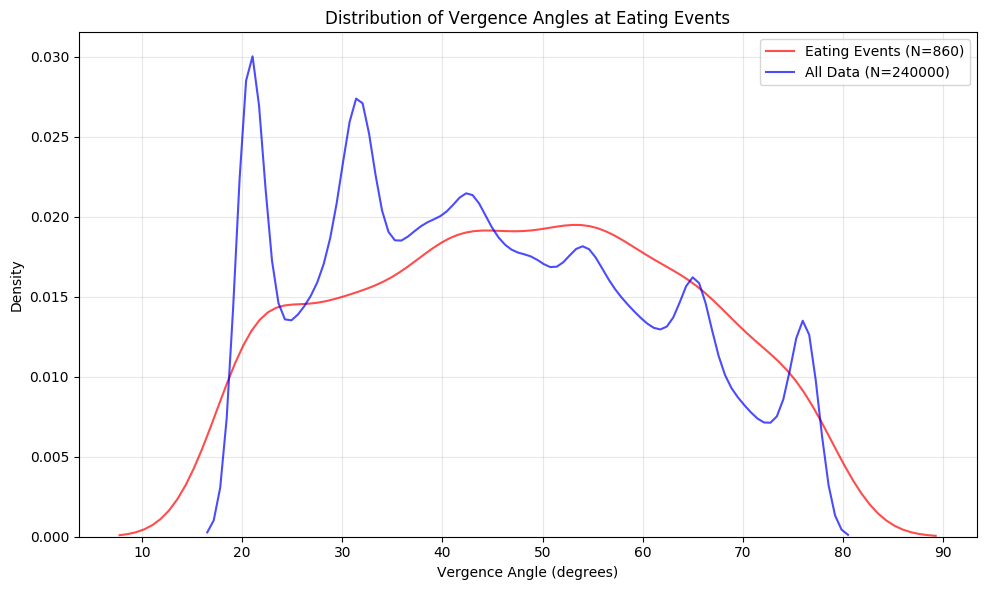

In [12]:
# Get vergence angles at eating events
eating_events = dff[dff['eating_event'] == True]
eating_vergence_angles = eating_events['vergence_angle_deg'].values

print(f"Total eating events: {len(eating_vergence_angles)}")
print(f"Vergence angle range at eating events: {eating_vergence_angles.min():.1f}° to {eating_vergence_angles.max():.1f}°")

# Create KDE plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=eating_vergence_angles, alpha=0.7, color='red', label=f'Eating Events (N={len(eating_vergence_angles)})')

# Also plot the overall distribution for comparison
sns.kdeplot(data=dff['vergence_angle_deg'], color='blue', alpha=0.7, label=f'All Data (N={len(dff)})')

plt.xlabel('Vergence Angle (degrees)')
plt.ylabel('Density')
plt.title('Distribution of Vergence Angles at Eating Events')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(f"{results_folder}/eating_vergence_angle_kde.png", dpi=300)
plt.show()


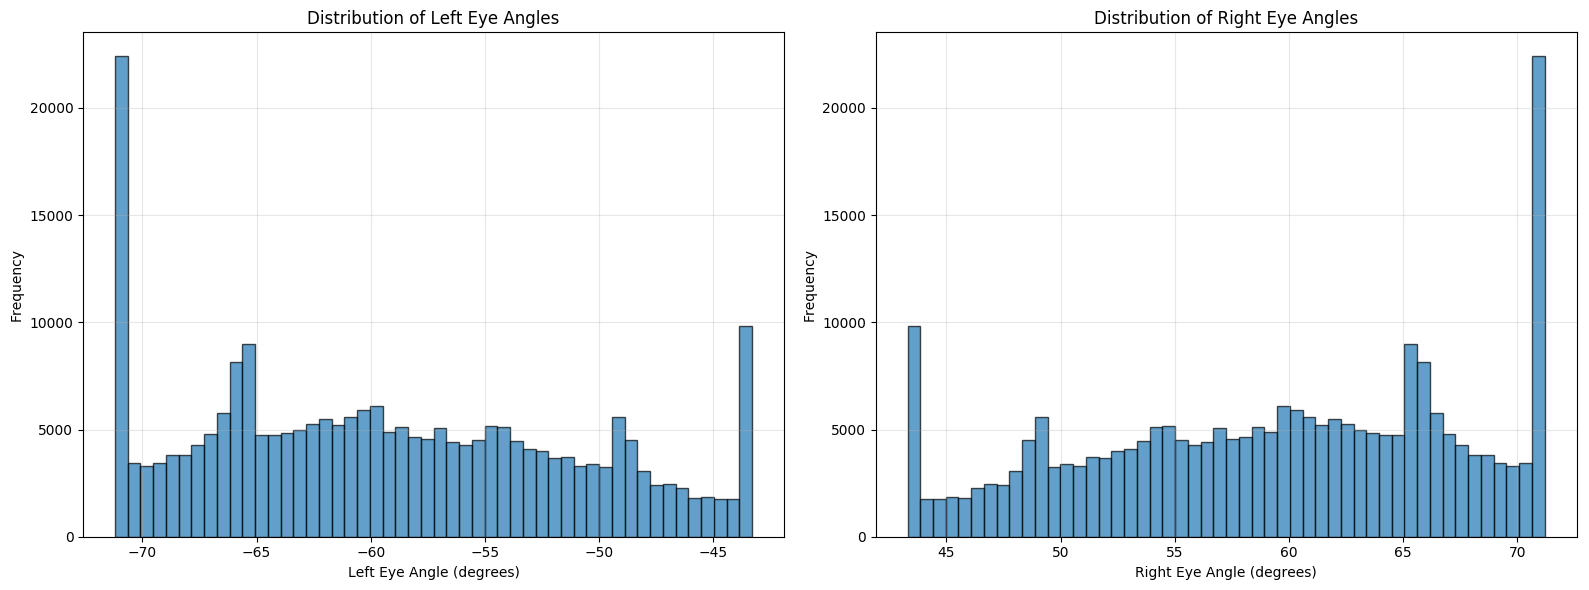

Left Eye Angle Statistics:
Mean left eye angle: -1.033 radians (-59.21 degrees)
Standard deviation: 0.141 radians (8.10 degrees)
Min left eye angle: -1.243 radians (-71.20 degrees)
Max left eye angle: -0.756 radians (-43.30 degrees)

Right Eye Angle Statistics:
Mean right eye angle: 1.033 radians (59.21 degrees)
Standard deviation: 0.141 radians (8.10 degrees)
Min right eye angle: 0.756 radians (43.30 degrees)
Max right eye angle: 1.243 radians (71.20 degrees)


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left eye angle histogram
ax1.hist(dff['left_eye_angle']*180/np.pi, bins=50, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Left Eye Angle (degrees)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Left Eye Angles')
ax1.grid(True, alpha=0.3)

# Right eye angle histogram
ax2.hist(dff['right_eye_angle']*180/np.pi, bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Right Eye Angle (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Right Eye Angles')
ax2.grid(True, alpha=0.3)

# Set the same y-axis scale for both histograms
max_freq = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, max_freq)
ax2.set_ylim(0, max_freq)

plt.tight_layout()
plt.savefig(f"{results_folder}/eye_angle_distribution.png", dpi=300)
plt.show()

# Print some basic statistics for both eye angles
print("Left Eye Angle Statistics:")
print(f"Mean left eye angle: {dff['left_eye_angle'].mean():.3f} radians ({dff['left_eye_angle'].mean()*180/np.pi:.2f} degrees)")
print(f"Standard deviation: {dff['left_eye_angle'].std():.3f} radians ({dff['left_eye_angle'].std()*180/np.pi:.2f} degrees)")
print(f"Min left eye angle: {dff['left_eye_angle'].min():.3f} radians ({dff['left_eye_angle'].min()*180/np.pi:.2f} degrees)")
print(f"Max left eye angle: {dff['left_eye_angle'].max():.3f} radians ({dff['left_eye_angle'].max()*180/np.pi:.2f} degrees)")

print("\nRight Eye Angle Statistics:")
print(f"Mean right eye angle: {dff['right_eye_angle'].mean():.3f} radians ({dff['right_eye_angle'].mean()*180/np.pi:.2f} degrees)")
print(f"Standard deviation: {dff['right_eye_angle'].std():.3f} radians ({dff['right_eye_angle'].std()*180/np.pi:.2f} degrees)")
print(f"Min right eye angle: {dff['right_eye_angle'].min():.3f} radians ({dff['right_eye_angle'].min()*180/np.pi:.2f} degrees)")
print(f"Max right eye angle: {dff['right_eye_angle'].max():.3f} radians ({dff['right_eye_angle'].max()*180/np.pi:.2f} degrees)")

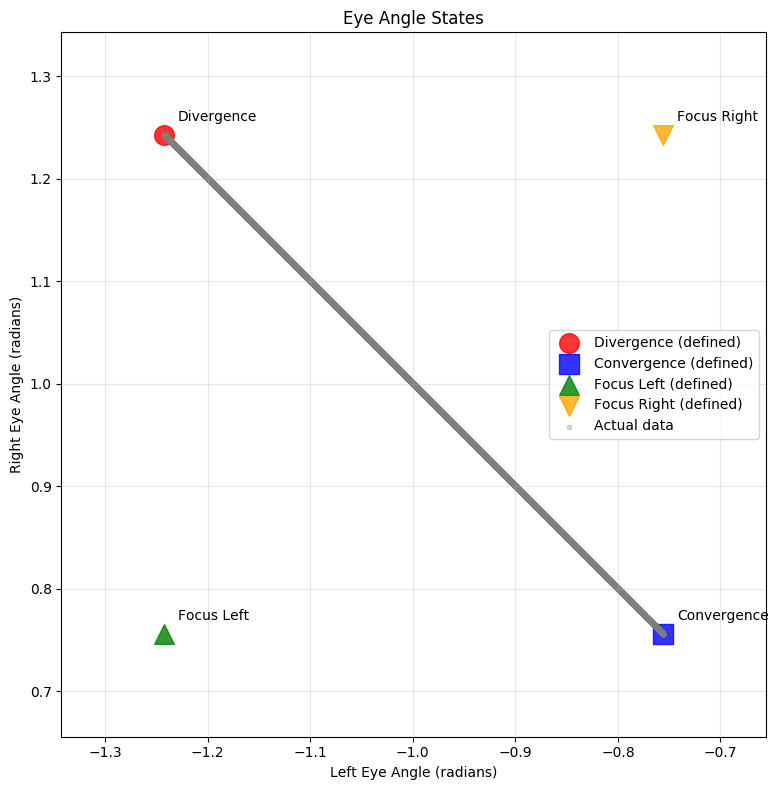

Distance from actual data to defined states:

Divergence:
  Target: Left=-1.24, Right=1.24
  Closest 10 points average distance: 0.000
  Overall average distance: 0.296
  Points within 0.1 radians: 45556

Convergence:
  Target: Left=-0.76, Right=0.76
  Closest 10 points average distance: 0.000
  Overall average distance: 0.393
  Points within 0.1 radians: 22321

Focus Left:
  Target: Left=-1.24, Right=0.76
  Closest 10 points average distance: 0.344
  Overall average distance: 0.398
  Points within 0.1 radians: 0

Focus Right:
  Target: Left=-0.76, Right=1.24
  Closest 10 points average distance: 0.344
  Overall average distance: 0.398
  Points within 0.1 radians: 0


In [14]:
# Create a visualization of the 4 eye angle states
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

left_divergence = cfg.FISH_CONSTANTS["min_left_vergence"]
left_convergence = cfg.FISH_CONSTANTS["max_left_vergence"]
right_divergence = cfg.FISH_CONSTANTS["min_right_vergence"]
right_convergence = cfg.FISH_CONSTANTS["max_right_vergence"]

# Define the four states with their eye angles
states_def = {
    'Divergence': {'left': left_divergence, 'right': right_divergence, 'color': 'red', 'marker': 'o'},
    'Convergence': {'left': left_convergence, 'right': right_convergence, 'color': 'blue', 'marker': 's'},
    'Focus Left': {'left': left_divergence, 'right': right_convergence, 'color': 'green', 'marker': '^'},
    'Focus Right': {'left': left_convergence, 'right': right_divergence, 'color': 'orange', 'marker': 'v'}
}

# Plot the defined states
for state_name, state_info in states_def.items():
    ax.scatter(state_info['left'], state_info['right'], 
              color=state_info['color'], marker=state_info['marker'], 
              s=200, alpha=0.8, label=f"{state_name} (defined)")

# Plot the actual data points from the dataframe
ax.scatter(dff['left_eye_angle'], dff['right_eye_angle'], 
          alpha=0.3, s=10, color='gray', label='Actual data')

# Add labels and formatting
ax.set_xlabel('Left Eye Angle (radians)')
ax.set_ylabel('Right Eye Angle (radians)')
ax.set_title('Eye Angle States')
ax.grid(True, alpha=0.3)
ax.legend()

# Add text annotations for the defined states
for state_name, state_info in states_def.items():
    ax.annotate(state_name, 
               xy=(state_info['left'], state_info['right']),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, ha='left')

# Set equal aspect ratio and adjust limits
ax.set_aspect('equal')
ax.set_xlim(cfg.FISH_CONSTANTS["min_left_vergence"] - 0.1, cfg.FISH_CONSTANTS["max_left_vergence"] + 0.1)
ax.set_ylim(cfg.FISH_CONSTANTS["max_right_vergence"] - 0.1, cfg.FISH_CONSTANTS["min_right_vergence"] + 0.1)

plt.tight_layout()
plt.savefig(f"{results_folder}/eye_angle_states.png", dpi=300)
plt.show()

# Print statistics about how close the actual data is to each defined state
print("Distance from actual data to defined states:")
print("=" * 50)

for state_name, state_info in states_def.items():
    # Calculate distances from all data points to this defined state
    distances = np.sqrt((dff['left_eye_angle'] - state_info['left'])**2 + 
                       (dff['right_eye_angle'] - state_info['right'])**2)
    
    # Find closest points
    closest_indices = distances.nsmallest(10).index
    
    print(f"\n{state_name}:")
    print(f"  Target: Left={state_info['left']:.2f}, Right={state_info['right']:.2f}")
    print(f"  Closest 10 points average distance: {distances.nsmallest(10).mean():.3f}")
    print(f"  Overall average distance: {distances.mean():.3f}")
    print(f"  Points within 0.1 radians: {(distances < 0.1).sum()}")

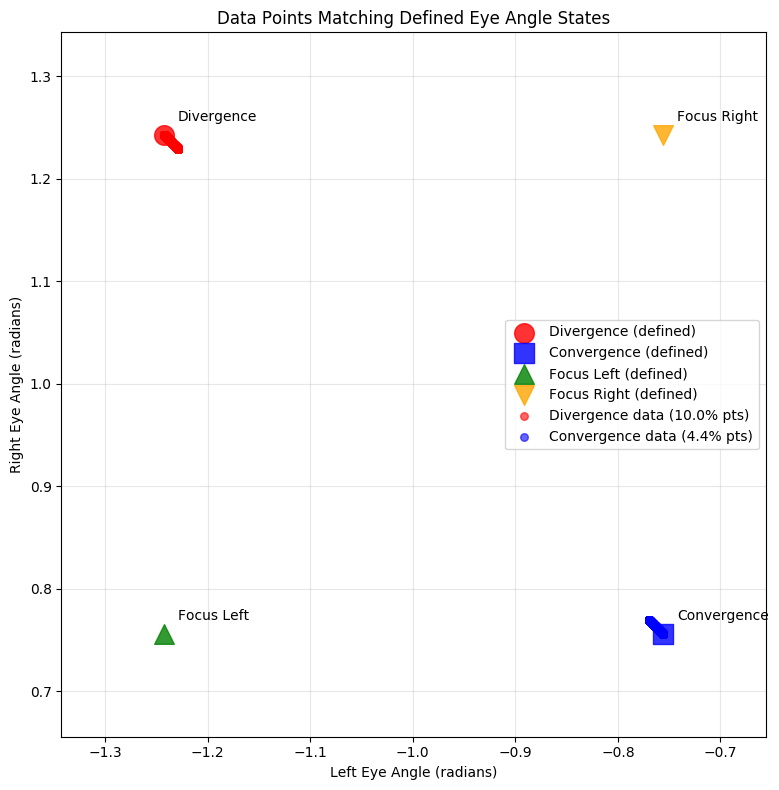

Total data points: 240000
Points matching defined states (within 0.02 radians): 34619
Percentage of data matching defined states: 14.4%

Breakdown by state:
Divergence: 23955 points (10.0%)
Convergence: 10664 points (4.4%)
Focus Left: 0 points (0.0%)
Focus Right: 0 points (0.0%)


In [15]:
# Create a visualization showing only data points that match the defined eye angle states
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the defined states
for state_name, state_info in states_def.items():
    ax.scatter(state_info['left'], state_info['right'], 
              color=state_info['color'], marker=state_info['marker'], 
              s=200, alpha=0.8, label=f"{state_name} (defined)")

# Filter data points that are close to each defined state
threshold = 0.02  # Slightly larger threshold to capture more points
matched_points = []

states_data = {}

for state_name, state_info in states_def.items():
    # Calculate distances from all data points to this defined state
    distances = np.sqrt((dff['left_eye_angle'] - state_info['left'])**2 + 
                       (dff['right_eye_angle'] - state_info['right'])**2)
    
    # Find points within threshold
    close_points = dff[distances < threshold]
    
    if len(close_points) > 0:
        ax.scatter(close_points['left_eye_angle'], close_points['right_eye_angle'], 
                  alpha=0.6, s=30, color=state_info['color'], 
                  label=f"{state_name} data ({len(close_points)/len(dff)*100:.1f}% pts)")
        matched_points.extend(close_points.index.tolist())
        
    states_data[state_name] = close_points

# Add labels and formatting
ax.set_xlabel('Left Eye Angle (radians)')
ax.set_ylabel('Right Eye Angle (radians)')
ax.set_title('Data Points Matching Defined Eye Angle States')
ax.grid(True, alpha=0.3)
ax.legend()

# Add text annotations for the defined states
for state_name, state_info in states_def.items():
    ax.annotate(state_name, 
               xy=(state_info['left'], state_info['right']),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, ha='left')

# Set equal aspect ratio and adjust limits
ax.set_aspect('equal')
ax.set_xlim(cfg.FISH_CONSTANTS["min_left_vergence"] - 0.1, cfg.FISH_CONSTANTS["max_left_vergence"] + 0.1)
ax.set_ylim(cfg.FISH_CONSTANTS["max_right_vergence"] - 0.1, cfg.FISH_CONSTANTS["min_right_vergence"] + 0.1)

plt.tight_layout()
plt.savefig(f"{results_folder}/matched_eye_angle_states.png", dpi=300)
plt.show()

# Print statistics
print(f"Total data points: {len(dff)}")
print(f"Points matching defined states (within {threshold} radians): {len(set(matched_points))}")
print(f"Percentage of data matching defined states: {len(set(matched_points))/len(dff)*100:.1f}%")

print(f"\nBreakdown by state:")
for state_name, state_info in states_def.items():
    distances = np.sqrt((dff['left_eye_angle'] - state_info['left'])**2 + 
                       (dff['right_eye_angle'] - state_info['right'])**2)
    close_points = dff[distances < threshold]
    print(f"{state_name}: {len(close_points)} points ({len(close_points)/len(dff)*100:.1f}%)")

/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


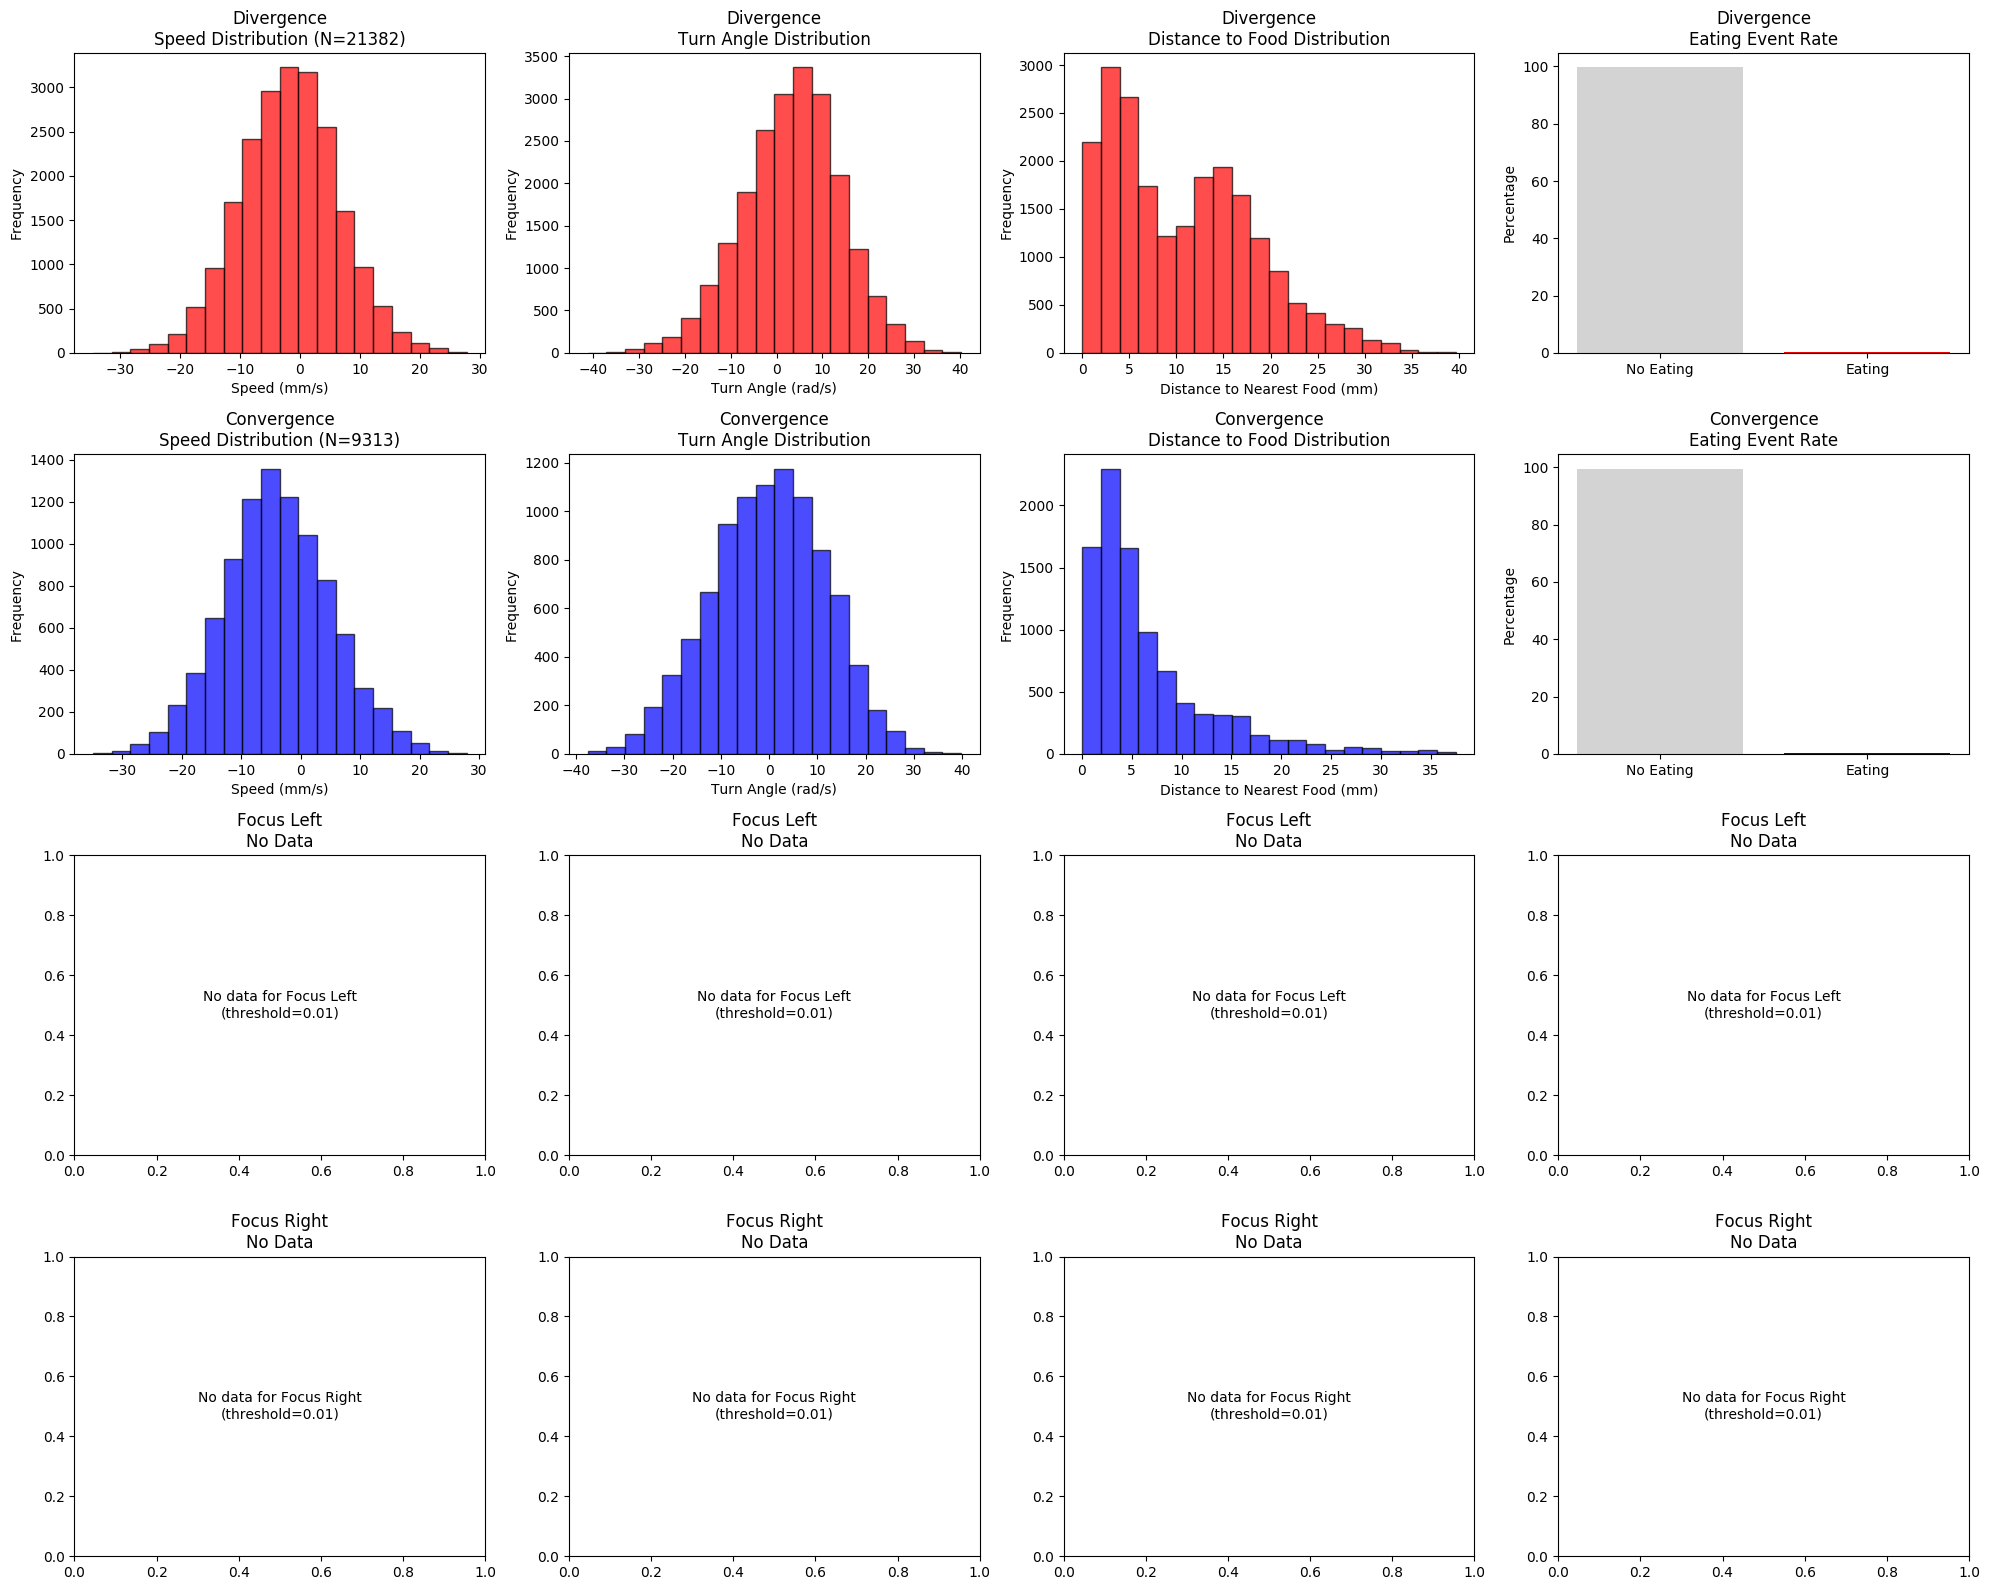

Summary statistics for defined eye angle states (threshold=0.01 radians):

Divergence Summary (N=21382):
  Mean speed: -1.681
  Mean turn angle: 3.350
  Eating event rate: 0.3%
  Mean energy: 4.0
  Mean distance to food: 10.735

Convergence Summary (N=9313):
  Mean speed: -3.913
  Mean turn angle: -0.119
  Eating event rate: 0.5%
  Mean energy: 1.5
  Mean distance to food: 6.643


In [16]:
# Analyze behavior for each defined eye angle state
fig, axes = plt.subplots(4, 4, figsize=(20, 16))


threshold = 0.01
state_data_list = []

for i, (state_name, state_info) in enumerate(states_def.items()):
    # Calculate distances from all data points to this defined state
    distances = np.sqrt((dff['left_eye_angle'] - state_info['left'])**2 + 
                       (dff['right_eye_angle'] - state_info['right'])**2)
    
    # Find points within threshold
    close_points = dff[distances < threshold].copy()
    
    if len(close_points) > 0:
        # Calculate distance to nearest food for each row
        distances_to_food = []
        for _, row in close_points.iterrows():
            agent_pos = np.array(row['position'])
            food_positions = np.array(row['food_positions'])
            
            # Calculate distances to all food items
            if food_positions is not None and len(food_positions) > 0:
                food_distances = np.linalg.norm(food_positions - agent_pos, axis=1)
                min_distance = np.min(food_distances)
                distances_to_food.append(min_distance)
            else:
                distances_to_food.append(np.nan)
        
        close_points['distance_to_food'] = distances_to_food
        state_data_list.append((close_points, state_name))
        
        # Speed distribution
        axes[i, 0].hist(close_points['speed'], bins=20, alpha=0.7, 
                       edgecolor='black', color=state_info['color'])
        axes[i, 0].set_title(f'{state_name}\nSpeed Distribution (N={len(close_points)})')
        axes[i, 0].set_xlabel('Speed (mm/s)')
        axes[i, 0].set_ylabel('Frequency')
        
        # Turn angle distribution
        axes[i, 1].hist(close_points['turn_angle'], bins=20, alpha=0.7, 
                       edgecolor='black', color=state_info['color'])
        axes[i, 1].set_title(f'{state_name}\nTurn Angle Distribution')
        axes[i, 1].set_xlabel('Turn Angle (rad/s)')
        axes[i, 1].set_ylabel('Frequency')
        
        # Distance to food distribution
        axes[i, 2].hist(close_points['distance_to_food'], bins=20, alpha=0.7, 
                       edgecolor='black', color=state_info['color'])
        axes[i, 2].set_title(f'{state_name}\nDistance to Food Distribution')
        axes[i, 2].set_xlabel('Distance to Nearest Food (mm)')
        axes[i, 2].set_ylabel('Frequency')
        
        # Eating event rate
        eating_rate = close_points['eating_event'].sum() / len(close_points) * 100
        axes[i, 3].bar(['No Eating', 'Eating'], 
                      [100-eating_rate, eating_rate], 
                      color=['lightgray', state_info['color']])
        axes[i, 3].set_title(f'{state_name}\nEating Event Rate')
        axes[i, 3].set_ylabel('Percentage')
    else:
        # No data for this state
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f'No data for {state_name}\n(threshold={threshold})', 
                           ha='center', va='center', transform=axes[i, j].transAxes)
            axes[i, j].set_title(f'{state_name}\nNo Data')

plt.tight_layout()
plt.savefig(f"{results_folder}/eye_angle_states_behavior_analysis.png", dpi=300)
plt.show()

# Print summary statistics for each state
print(f"Summary statistics for defined eye angle states (threshold={threshold} radians):")
print("=" * 80)

for state_data, state_name in state_data_list:
    eating_rate = state_data['eating_event'].sum() / len(state_data) * 100
    
    print(f"\n{state_name} Summary (N={len(state_data)}):")
    print(f"  Mean speed: {state_data['speed'].mean():.3f}")
    print(f"  Mean turn angle: {state_data['turn_angle'].mean():.3f}")
    print(f"  Eating event rate: {eating_rate:.1f}%")
    print(f"  Mean energy: {state_data['energy'].mean():.1f}")
    print(f"  Mean distance to food: {state_data['distance_to_food'].mean():.3f}")

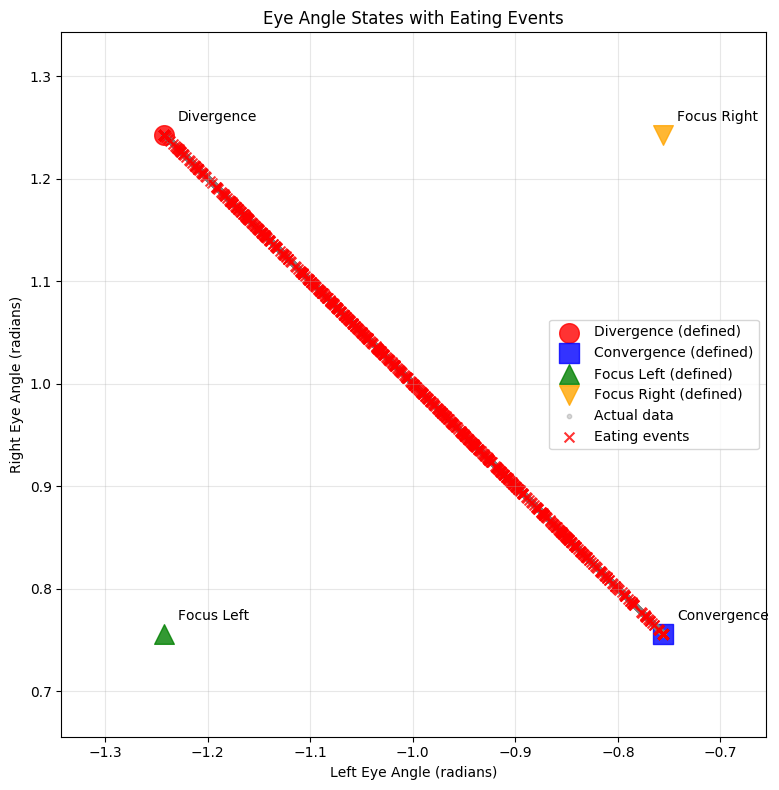

Total eating events: 860
Eating events eye angle statistics:
  Left eye angle range: -1.243 to -0.756
  Right eye angle range: 0.756 to 1.243


In [17]:
# Create a visualization of the 4 eye angle states with eating events marked
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Plot the defined states
for state_name, state_info in states_def.items():
    ax.scatter(state_info['left'], state_info['right'], 
              color=state_info['color'], marker=state_info['marker'], 
              s=200, alpha=0.8, label=f"{state_name} (defined)")

# Plot the actual data points from the dataframe
ax.scatter(dff['left_eye_angle'], dff['right_eye_angle'], 
          alpha=0.3, s=10, color='gray', label='Actual data')

# Plot eating events as red X markers
eating_data = dff[dff['eating_event'] == True]
if len(eating_data) > 0:
    ax.scatter(eating_data['left_eye_angle'], eating_data['right_eye_angle'], 
              marker='x', s=50, color='red', alpha=0.8, label='Eating events')

# Add labels and formatting
ax.set_xlabel('Left Eye Angle (radians)')
ax.set_ylabel('Right Eye Angle (radians)')
ax.set_title('Eye Angle States with Eating Events')
ax.grid(True, alpha=0.3)
ax.legend()

# Add text annotations for the defined states
for state_name, state_info in states_def.items():
    ax.annotate(state_name, 
               xy=(state_info['left'], state_info['right']),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, ha='left')

# Set equal aspect ratio and adjust limits
ax.set_aspect('equal')
ax.set_xlim(cfg.FISH_CONSTANTS["min_left_vergence"] - 0.1, cfg.FISH_CONSTANTS["max_left_vergence"] + 0.1)
ax.set_ylim(cfg.FISH_CONSTANTS["max_right_vergence"] - 0.1, cfg.FISH_CONSTANTS["min_right_vergence"] + 0.1)

plt.tight_layout()
plt.savefig(f"{results_folder}/eye_angle_states_with_eating_events.png", dpi=300)
plt.show()

print(f"Total eating events: {len(eating_data)}")
if len(eating_data) > 0:
    print(f"Eating events eye angle statistics:")
    print(f"  Left eye angle range: {eating_data['left_eye_angle'].min():.3f} to {eating_data['left_eye_angle'].max():.3f}")
    print(f"  Right eye angle range: {eating_data['right_eye_angle'].min():.3f} to {eating_data['right_eye_angle'].max():.3f}")

### Arena info

Number of unique episodes: 30
Number of unique environments: 10
Episodes per environment: [30, 30, 30, 30, 30, 30, 30, 30, 30, 30]
Arena Summary:
     env_id  episode_index    arena_type arena_size  arena_width  \
0         0              0  UniformArena   (73, 97)           73   
1         0              1  UniformArena   (72, 76)           72   
2         0              2  UniformArena   (45, 84)           45   
3         0              3  UniformArena   (42, 43)           42   
4         0              4  UniformArena   (90, 35)           90   
..      ...            ...           ...        ...          ...   
295       9             25  UniformArena   (68, 98)           68   
296       9             26  UniformArena   (85, 35)           85   
297       9             27  UniformArena   (45, 62)           45   
298       9             28  UniformArena   (89, 75)           89   
299       9             29  UniformArena   (51, 77)           51   

     arena_height  arena_area  patch_

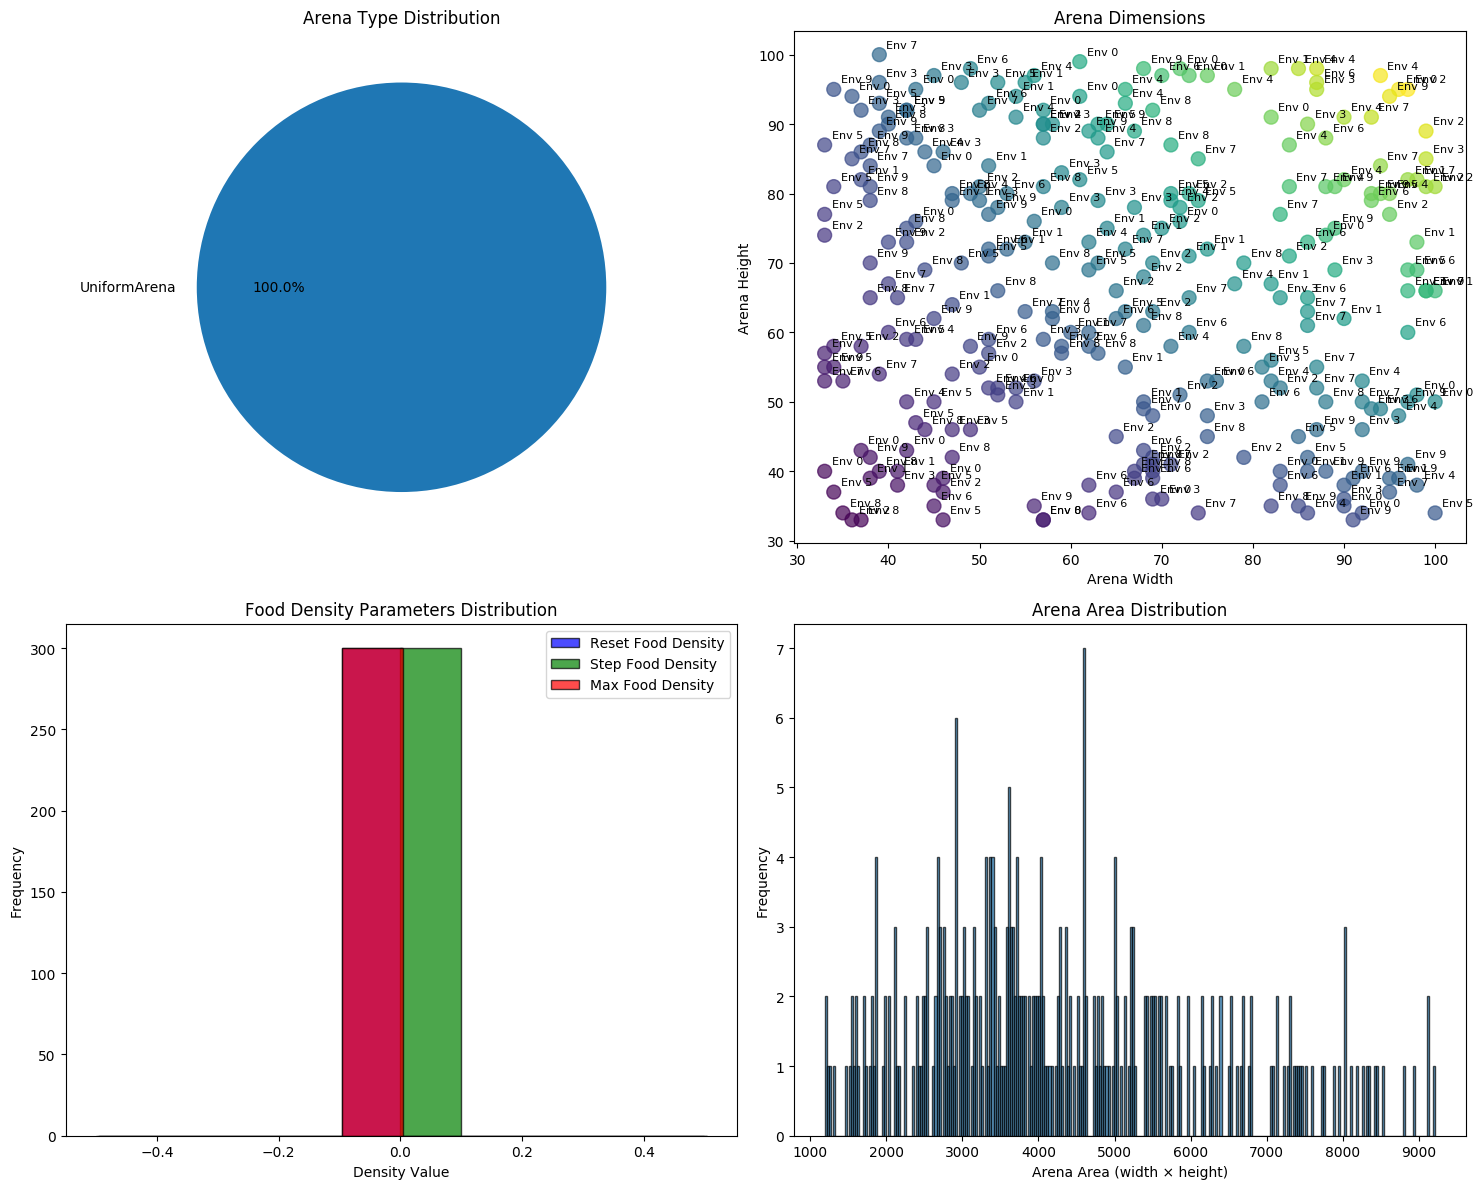

In [18]:
# Food density histogram instead of bar chart by environment
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Create arena summary dataframe
# Print episode information
print(f"Number of unique episodes: {dff['episode_index'].nunique()}")
print(f"Number of unique environments: {dff['env_id'].nunique()}")
print(f"Episodes per environment: {dff.groupby('env_id')['episode_index'].nunique().tolist()}")
arena_summary = dff.groupby(['env_id', 'episode_index']).first()[['arena_type', 'arena_size']].reset_index()

# Extract arena dimensions and calculate areas
arena_summary['arena_width'] = arena_summary['arena_size'].apply(lambda x: x[0])
arena_summary['arena_height'] = arena_summary['arena_size'].apply(lambda x: x[1])
arena_summary['arena_area'] = arena_summary['arena_width'] * arena_summary['arena_height']

# Add food density parameters
food_params = dff.groupby('env_id')[['patch_kwargs.reset_food_density', 
                                     'patch_kwargs.step_food_density', 
                                     'patch_kwargs.max_food_density']].first()
arena_summary = arena_summary.merge(food_params, left_on='env_id', right_index=True)

print("Arena Summary:")
print(arena_summary)

# Arena type distribution
arena_type_counts = arena_summary['arena_type'].value_counts()
axes[0, 0].pie(arena_type_counts.values, labels=arena_type_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Arena Type Distribution')

# Arena size distribution
axes[0, 1].scatter(arena_summary['arena_width'], arena_summary['arena_height'], 
                  s=100, alpha=0.7, c=arena_summary['arena_area'], cmap='viridis')
axes[0, 1].set_xlabel('Arena Width')
axes[0, 1].set_ylabel('Arena Height')
axes[0, 1].set_title('Arena Dimensions')
for i, (w, h) in enumerate(zip(arena_summary['arena_width'], arena_summary['arena_height'])):
    axes[0, 1].annotate(f'Env {arena_summary.iloc[i]["env_id"]}', 
                       (w, h), xytext=(5, 5), textcoords='offset points', fontsize=8)

# Food density histograms
food_densities = [
    arena_summary['patch_kwargs.reset_food_density'],
    arena_summary['patch_kwargs.step_food_density'], 
    arena_summary['patch_kwargs.max_food_density']
]
labels = ['Reset Food Density', 'Step Food Density', 'Max Food Density']
colors = ['blue', 'green', 'red']

for density, label, color in zip(food_densities, labels, colors):
    axes[1, 0].hist(density, bins=10, alpha=0.7, label=label, color=color, edgecolor='black')

axes[1, 0].set_xlabel('Density Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Food Density Parameters Distribution')
axes[1, 0].legend()

# Arena area histogram
axes[1, 1].hist(arena_summary['arena_area'], bins=len(arena_summary), alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Arena Area (width × height)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Arena Area Distribution')

plt.tight_layout()
plt.savefig(f"{results_folder}/arena_analysis.png", dpi=300)
plt.show()


### Behavior plots

In [19]:
# Example usage
# plot_agent_trajectories_with_eating_events(dff)

### Movements around eating

Agent 0 speed_changes.shape (854, 11)
Agent 0 trajectory_curvatures.shape (854, 11)
Agent 0 vergence_angles.shape (854, 11)


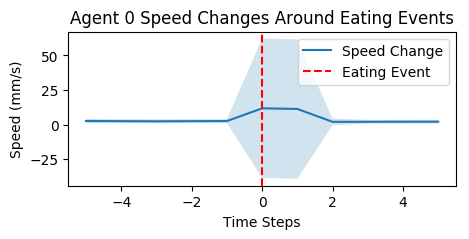

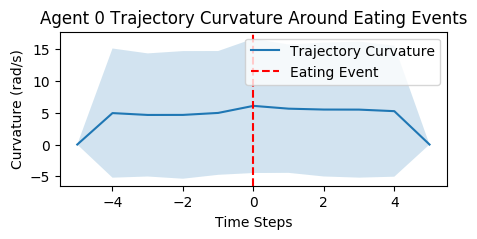

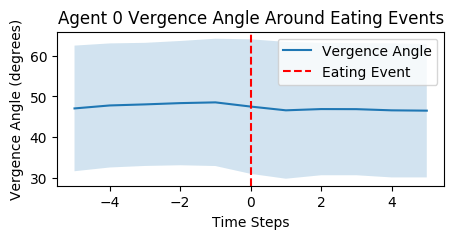

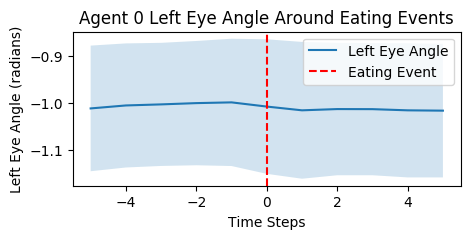

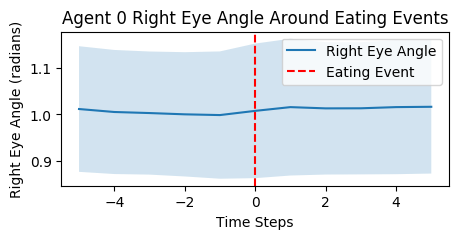

In [20]:
import cfg
from utils_behavior import plot_behavioral_maneuvers_around_eating

plot_behavioral_maneuvers_around_eating(dff, results_folder)

Food Tracking Analysis Results:
Total tracking sequences: 3468

Summary by outcome:
        tracking_duration               mean_vergence_angle         \
                    count   mean    std                mean    std   
outcome                                                              
miss                 2646  54.38  52.53               46.82  12.15   
success               822  59.22  53.08               45.69  11.22   

        initial_vergence_angle        final_vergence_angle         
                          mean    std                 mean    std  
outcome                                                            
miss                     43.97  16.19                46.96  15.65  
success                  42.39  15.48                48.61  15.94  


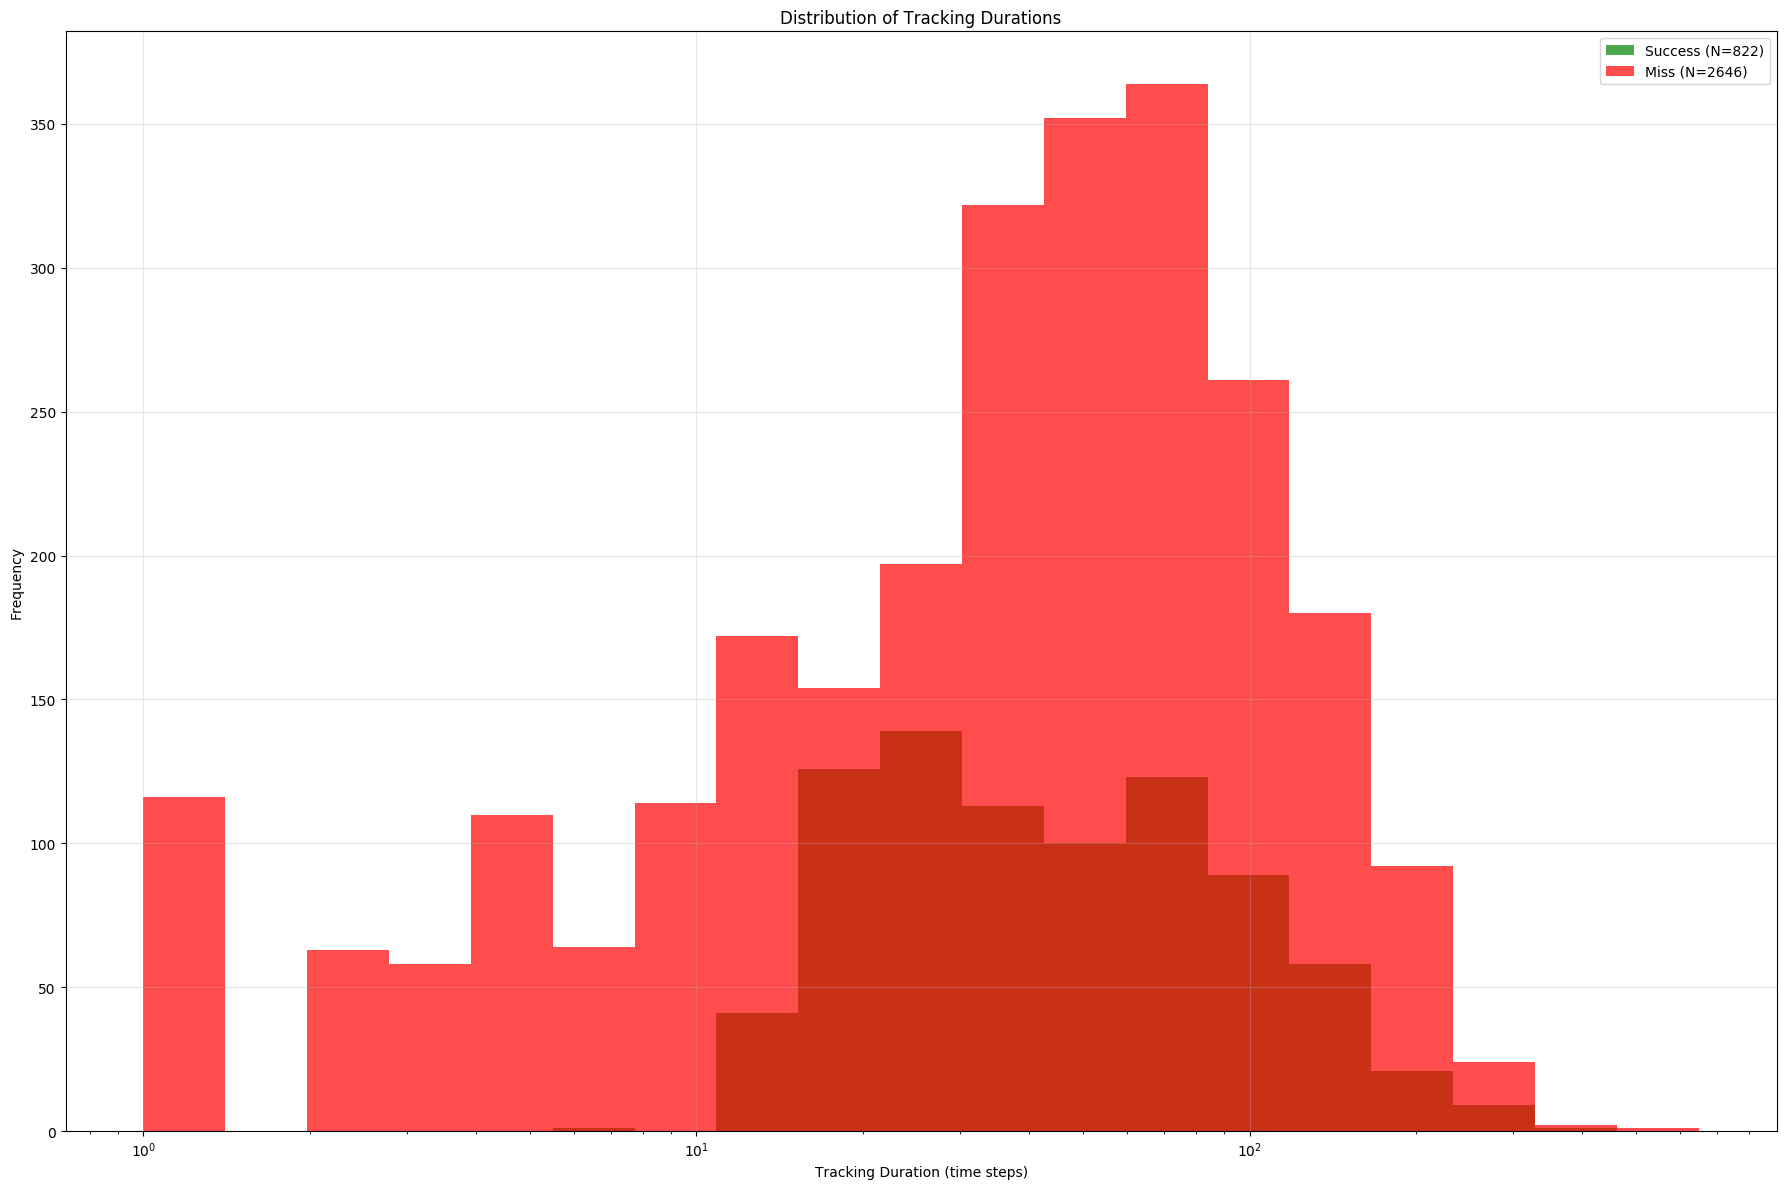

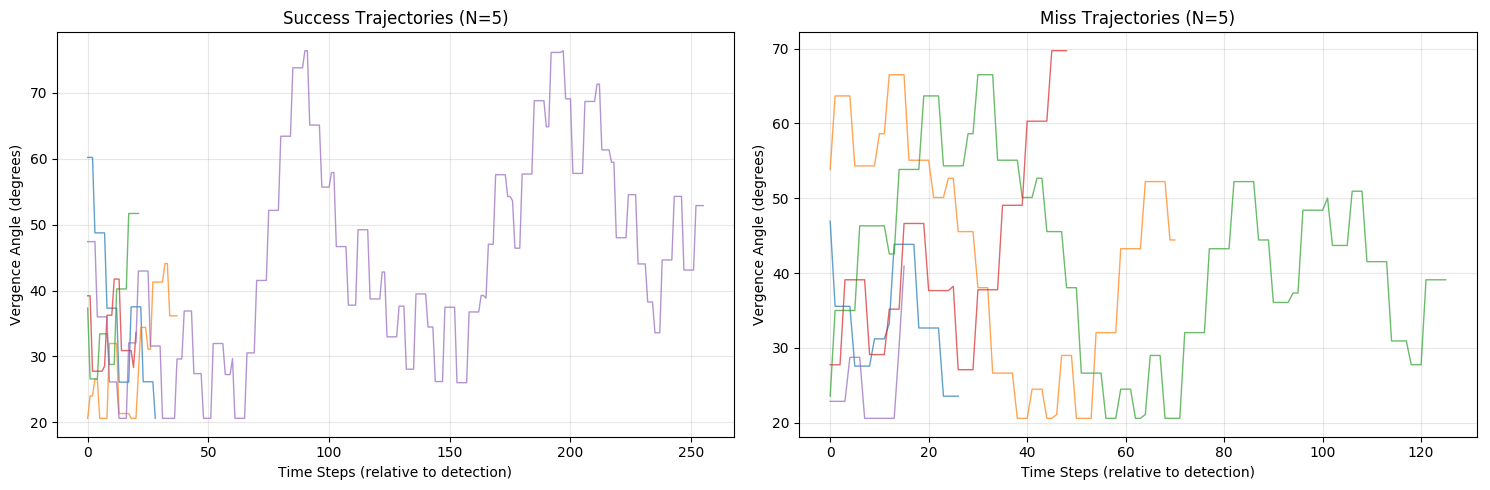

In [ ]:
from scipy.stats import mannwhitneyu, ttest_ind
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils_behavior import analyze_vergence_during_food_tracking

# Perform the analysis
tracking_sequences_df = analyze_vergence_during_food_tracking(dff)

print(f"Food Tracking Analysis Results:")
print(f"=" * 50)
print(f"Total tracking sequences: {len(tracking_sequences_df)}")

# Summary by outcome
outcome_summary = tracking_sequences_df.groupby('outcome').agg({
    'tracking_duration': ['count', 'mean', 'std'],
    'mean_vergence_angle': ['mean', 'std'],
    'initial_vergence_angle': ['mean', 'std'],
    'final_vergence_angle': ['mean', 'std']
}).round(2)

print(f"\nSummary by outcome:")
print(outcome_summary)

# Create visualizations
fig, axes = plt.subplots(1, 1, figsize=(18, 12))

success_data = tracking_sequences_df[tracking_sequences_df['outcome'] == 'success']
miss_data = tracking_sequences_df[tracking_sequences_df['outcome'] == 'miss']

# 1. Distribution of tracking durations by outcome (with log scale bins)
success_durations = success_data['tracking_duration'].values
miss_durations = miss_data['tracking_duration'].values

# Create log-spaced bins for better visualization with log scale
min_duration = min(success_durations.min(), miss_durations.min())
max_duration = max(success_durations.max(), miss_durations.max())
log_bins = np.logspace(np.log10(max(1, min_duration)), np.log10(max_duration), 20)

axes.hist(success_durations, bins=log_bins, alpha=0.7, 
                label=f'Success (N={len(success_data)})', color='green')
axes.hist(miss_durations, bins=log_bins, alpha=0.7, 
                label=f'Miss (N={len(miss_data)})', color='red')
axes.set_xlabel('Tracking Duration (time steps)')
axes.set_ylabel('Frequency')
axes.set_title('Distribution of Tracking Durations')
axes.set_xscale('log')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/food_tracking_analysis.png", dpi=300)
plt.show()

# Plot sample trajectories
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Success trajectories
sample_success = success_data.head(5)
for i, (_, row) in enumerate(sample_success.iterrows()):
    time_steps = np.arange(len(row['vergence_angles']))
    axes[0].plot(time_steps, row['vergence_angles'], alpha=0.7, linewidth=1)

axes[0].set_xlabel('Time Steps (relative to detection)')
axes[0].set_ylabel('Vergence Angle (degrees)')
axes[0].set_title(f'Success Trajectories (N={len(sample_success)})')
axes[0].grid(True, alpha=0.3)

# Miss trajectories
sample_miss = miss_data.head(5)
for i, (_, row) in enumerate(sample_miss.iterrows()):
    time_steps = np.arange(len(row['vergence_angles']))
    axes[1].plot(time_steps, row['vergence_angles'], alpha=0.7, linewidth=1)

axes[1].set_xlabel('Time Steps (relative to detection)')
axes[1].set_ylabel('Vergence Angle (degrees)')
axes[1].set_title(f'Miss Trajectories (N={len(sample_miss)})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/sample_tracking_trajectories.png", dpi=300)
plt.show()

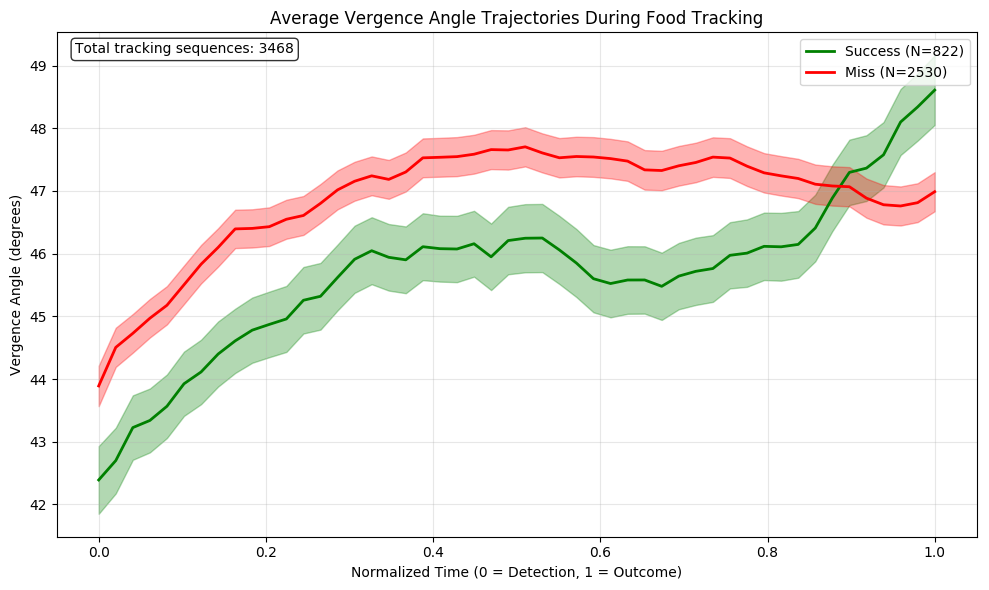

In [ ]:
from utils_behavior import calculate_avg_vergence_by_outcome, interpolate_trajectories

# Calculate trajectories
success_trajectories, miss_trajectories = calculate_avg_vergence_by_outcome(tracking_sequences_df)
success_interpolated, miss_interpolated, time_grid = interpolate_trajectories(success_trajectories, miss_trajectories)

# Calculate means and standard errors
if success_interpolated:
    success_mean = np.mean(success_interpolated, axis=0)
    success_sem = np.std(success_interpolated, axis=0) / np.sqrt(len(success_interpolated))
else:
    success_mean = np.array([])
    success_sem = np.array([])

if miss_interpolated:
    miss_mean = np.mean(miss_interpolated, axis=0)
    miss_sem = np.std(miss_interpolated, axis=0) / np.sqrt(len(miss_interpolated))
else:
    miss_mean = np.array([])
    miss_sem = np.array([])

# Create the plot
plt.figure(figsize=(10, 6))

# Plot success trajectory
if len(success_mean) > 0:
    plt.plot(time_grid, success_mean, 'g-', linewidth=2, label=f'Success (N={len(success_interpolated)})')
    plt.fill_between(time_grid, 
                     success_mean - success_sem, 
                     success_mean + success_sem, 
                     alpha=0.3, color='green')

# Plot miss trajectory
if len(miss_mean) > 0:
    plt.plot(time_grid, miss_mean, 'r-', linewidth=2, label=f'Miss (N={len(miss_interpolated)})')
    plt.fill_between(time_grid, 
                     miss_mean - miss_sem, 
                     miss_mean + miss_sem, 
                     alpha=0.3, color='red')

plt.xlabel('Normalized Time (0 = Detection, 1 = Outcome)')
plt.ylabel('Vergence Angle (degrees)')
plt.title('Average Vergence Angle Trajectories During Food Tracking')
plt.legend()
plt.grid(True, alpha=0.3)

# Add summary statistics
plt.text(0.02, 0.98, f'Total tracking sequences: {len(tracking_sequences_df)}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{results_folder}/vergence_angle_trajectories.png", dpi=300)
plt.show()

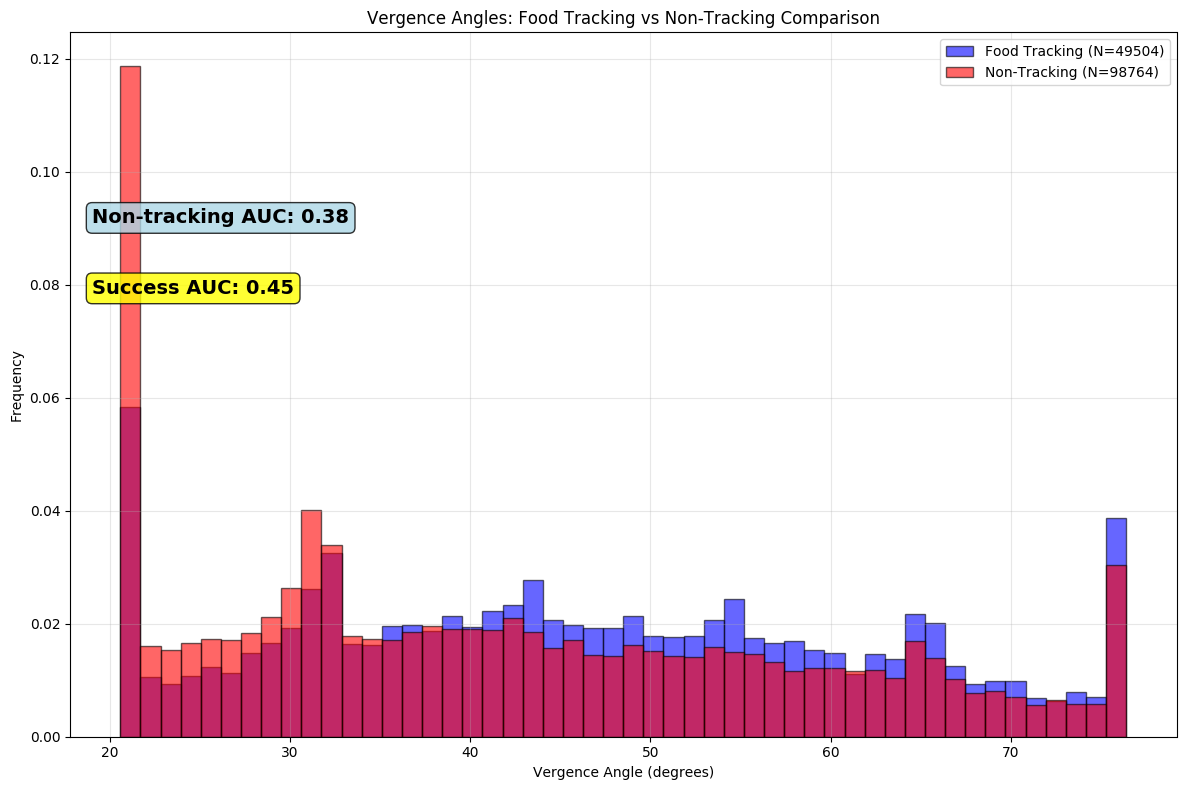

In [ ]:
from utils_behavior import non_tracking_data, calculate_auc_hunting_no_hunting

non_tracking_vergence = non_tracking_data(dff, tracking_sequences_df)
avg_auc, non_tracking_auc = calculate_auc_hunting_no_hunting(success_trajectories, non_tracking_vergence)

with open(os.path.join(results_folder, "performance_metrics.txt"), "a") as f:
        f.write(f"Average AUC (Success): {avg_auc:.2f}\n")
        f.write(f"Average AUC (Non-Tracking): {non_tracking_auc:.2f}\n")

# Create comparison histograms of vergence angles (overlapping)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Extract vergence angles from tracking results
tracking_vergence = []
for time_points, angles in success_trajectories:
        tracking_vergence.extend(angles)
tracking_vergence = np.array(tracking_vergence)
# Plot both KDEs on the same axes
ax.hist(np.abs(tracking_vergence), bins=50, alpha=0.6, color='blue', edgecolor='black',
        label=f'Food Tracking (N={len(tracking_vergence)})', density=True)
ax.hist(np.abs(non_tracking_vergence), bins=50, alpha=0.6, color='red', edgecolor='black',
        label=f'Non-Tracking (N={len(non_tracking_vergence)})', density=True)


# Add AUC text
plt.text(0.02, 0.75, f'Non-tracking AUC: {non_tracking_auc:.2f}', 
         transform=ax.transAxes, fontsize=14, fontweight='bold',
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.text(0.02, 0.65, f'Success AUC: {avg_auc:.2f}', 
         transform=ax.transAxes, fontsize=14, fontweight='bold',
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Add labels and formatting
ax.set_xlabel('Vergence Angle (degrees)')
ax.set_ylabel('Frequency')
ax.set_title('Vergence Angles: Food Tracking vs Non-Tracking Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/tracking_vs_non_tracking_vergence_comparison.png", dpi=300)
plt.show()


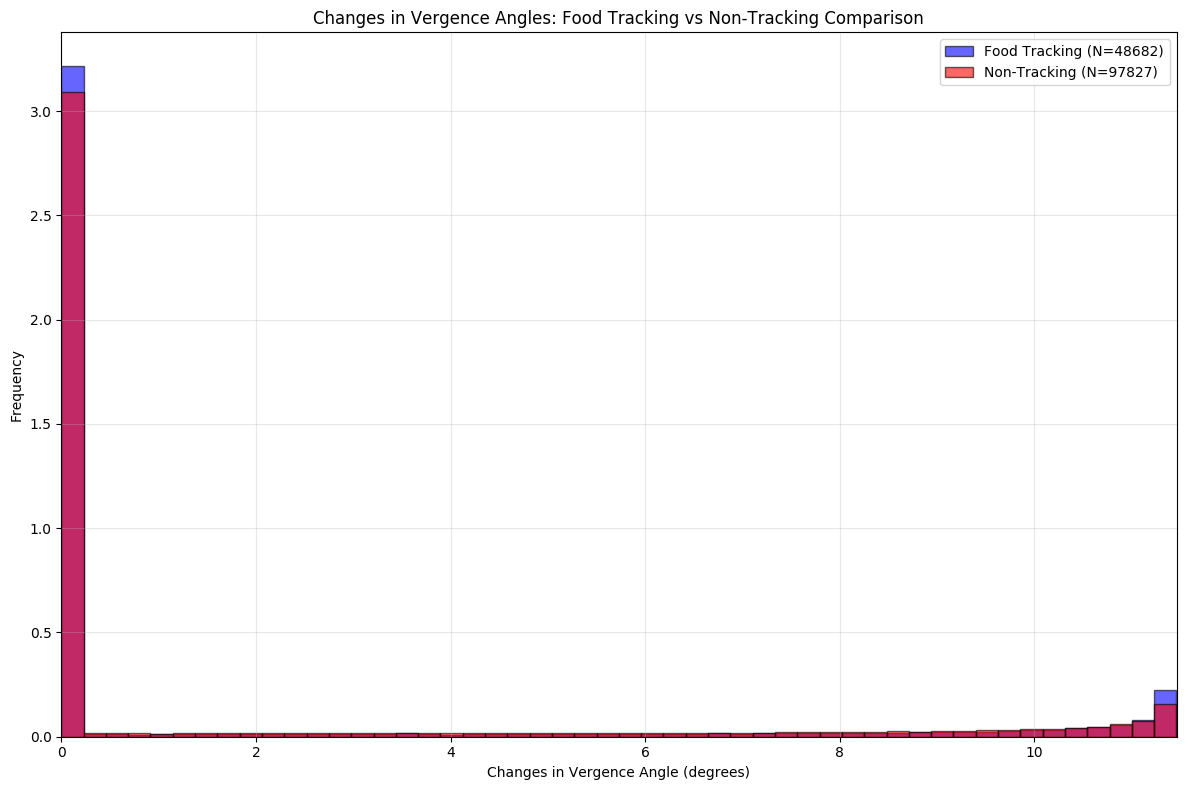

In [24]:
# Create comparison histograms of vergence angles (overlapping)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Extract vergence angles from tracking results
tracking_vergence_changes = []
for time_points, angles in success_trajectories:
    if len(angles) > 1:
        angle_changes = np.diff(angles)
        tracking_vergence_changes.extend(angle_changes)
tracking_vergence_changes = np.array(tracking_vergence_changes)

non_tracking_vergence_changes = []
if len(non_tracking_vergence) > 1:
    non_tracking_vergence_changes = np.diff(non_tracking_vergence)
non_tracking_vergence_changes = np.array(non_tracking_vergence_changes)

# Discard changes greater than the threshold (in between hunting sequences)
threshold = 2 * cfg.FISH_CONSTANTS["max_eye_turn"] * 180 / np.pi
non_tracking_vergence_changes = non_tracking_vergence_changes[np.abs(non_tracking_vergence_changes) <= threshold]

# Plot both histograms on the same axes with transparency
ax.hist(np.abs(tracking_vergence_changes), bins=50, alpha=0.6, color='blue', edgecolor='black',
        label=f'Food Tracking (N={len(tracking_vergence_changes)})', density=True)
ax.hist(np.abs(non_tracking_vergence_changes), bins=50, alpha=0.6, color='red', edgecolor='black',
        label=f'Non-Tracking (N={len(non_tracking_vergence_changes)})', density=True)

ax.set_xlabel('Changes in Vergence Angle (degrees)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 2 * cfg.FISH_CONSTANTS["max_eye_turn"] * 180 / np.pi)
ax.set_title('Changes in Vergence Angles: Food Tracking vs Non-Tracking Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/tracking_vs_non_tracking_vergence_changes_comparison.png", dpi=300)

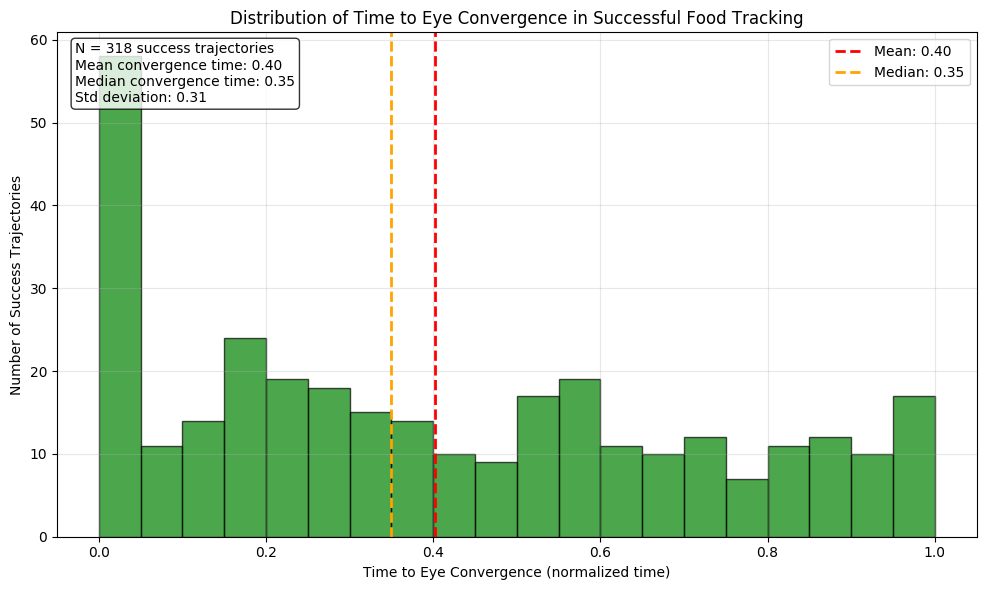

In [25]:
from utils_behavior import time_to_convergence

convergence_times = time_to_convergence(success_trajectories)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(convergence_times, bins=20, alpha=0.7, edgecolor='black', color='green')
plt.xlabel('Time to Eye Convergence (normalized time)')
plt.ylabel('Number of Success Trajectories')
plt.title('Distribution of Time to Eye Convergence in Successful Food Tracking')
plt.grid(True, alpha=0.3)

# Add summary statistics
mean_convergence_time = np.mean(convergence_times)
median_convergence_time = np.median(convergence_times)

plt.axvline(mean_convergence_time, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_convergence_time:.2f}')
plt.axvline(median_convergence_time, color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {median_convergence_time:.2f}')

plt.legend()

# Add text with summary statistics
stats_text = f'N = {len(convergence_times)} success trajectories\n'
stats_text += f'Mean convergence time: {mean_convergence_time:.2f}\n'
stats_text += f'Median convergence time: {median_convergence_time:.2f}\n'
stats_text += f'Std deviation: {np.std(convergence_times):.2f}'

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{results_folder}/convergence_time_histogram.png", dpi=300)
plt.show()

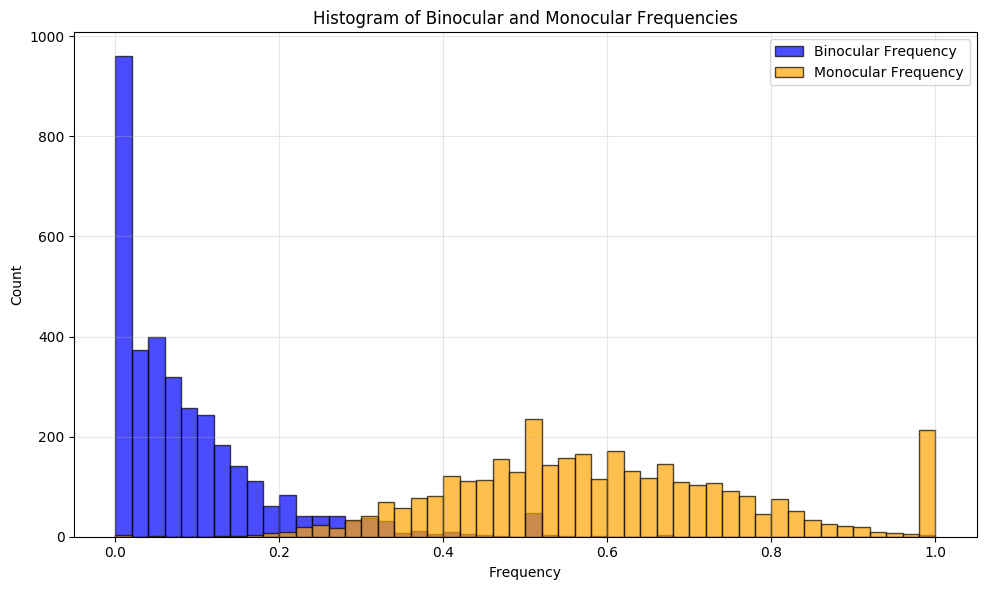

In [ ]:
# Compute monocular frequency
tracking_sequences_df['monocular_frequency'] = tracking_sequences_df['detected_frequency'] - tracking_sequences_df['binocular_frequency']

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(tracking_sequences_df['binocular_frequency'], bins=50, alpha=0.7, label='Binocular Frequency', color='blue', edgecolor='black')
plt.hist(tracking_sequences_df['monocular_frequency'], bins=50, alpha=0.7, label='Monocular Frequency', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Histogram of Binocular and Monocular Frequencies during Food Tracking')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.savefig(f"{results_folder}/binocular_monocular_histogram.png", dpi=300)

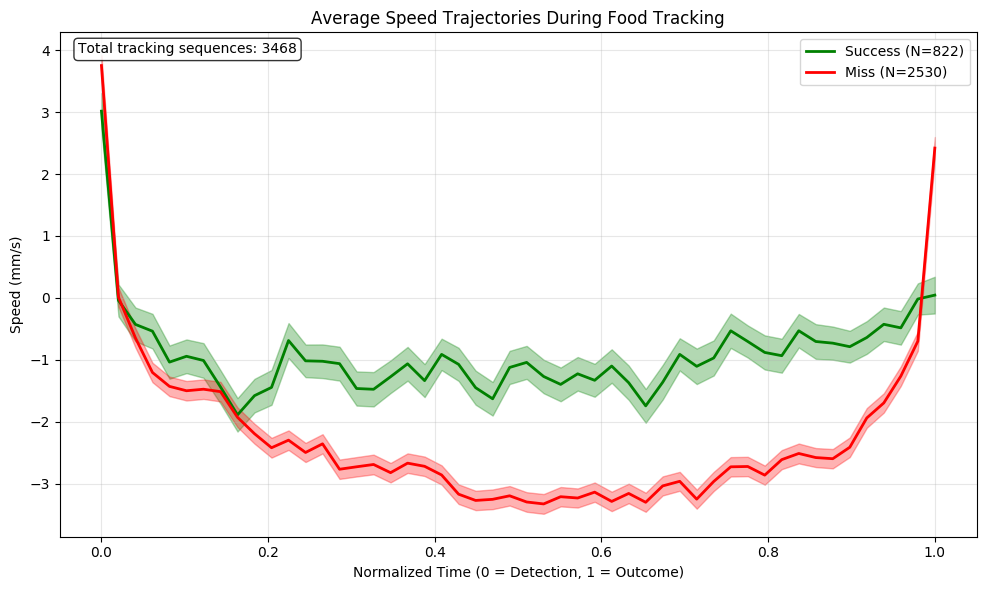

In [ ]:
from utils_behavior import calculate_avg_speed_by_outcome

success_trajectories, miss_trajectories = calculate_avg_speed_by_outcome(tracking_sequences_df)
success_interpolated, miss_interpolated, time_grid = interpolate_trajectories(success_trajectories, miss_trajectories)

# Calculate means and standard errors
if success_interpolated:
    success_mean = np.nanmean(success_interpolated, axis=0)
    success_sem = np.nanstd(success_interpolated, axis=0) / np.sqrt(len(success_interpolated))
else:
    success_mean = np.array([])
    success_sem = np.array([])

if miss_interpolated:
    miss_mean = np.nanmean(miss_interpolated, axis=0)
    miss_sem = np.nanstd(miss_interpolated, axis=0) / np.sqrt(len(miss_interpolated))
else:
    miss_mean = np.array([])
    miss_sem = np.array([])

# Create the plot
plt.figure(figsize=(10, 6))

# Plot success trajectory
if len(success_mean) > 0:
    plt.plot(time_grid, success_mean, 'g-', linewidth=2, label=f'Success (N={len(success_interpolated)})')
    plt.fill_between(time_grid, 
                     success_mean - success_sem, 
                     success_mean + success_sem, 
                     alpha=0.3, color='green')

# Plot miss trajectory
if len(miss_mean) > 0:
    plt.plot(time_grid, miss_mean, 'r-', linewidth=2, label=f'Miss (N={len(miss_interpolated)})')
    plt.fill_between(time_grid, 
                     miss_mean - miss_sem, 
                     miss_mean + miss_sem, 
                     alpha=0.3, color='red')

plt.xlabel('Normalized Time (0 = Detection, 1 = Outcome)')
plt.ylabel('Speed (mm/s)')
plt.title('Average Speed Trajectories During Food Tracking')
plt.legend()
plt.grid(True, alpha=0.3)

# Add summary statistics
plt.text(0.02, 0.98, f'Total tracking sequences: {len(tracking_sequences_df)}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{results_folder}/speed_trajectories.png", dpi=300)
plt.show()

Analyzed 790 food detection events
Total data points: 183095


/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/axes/_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/axes/_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


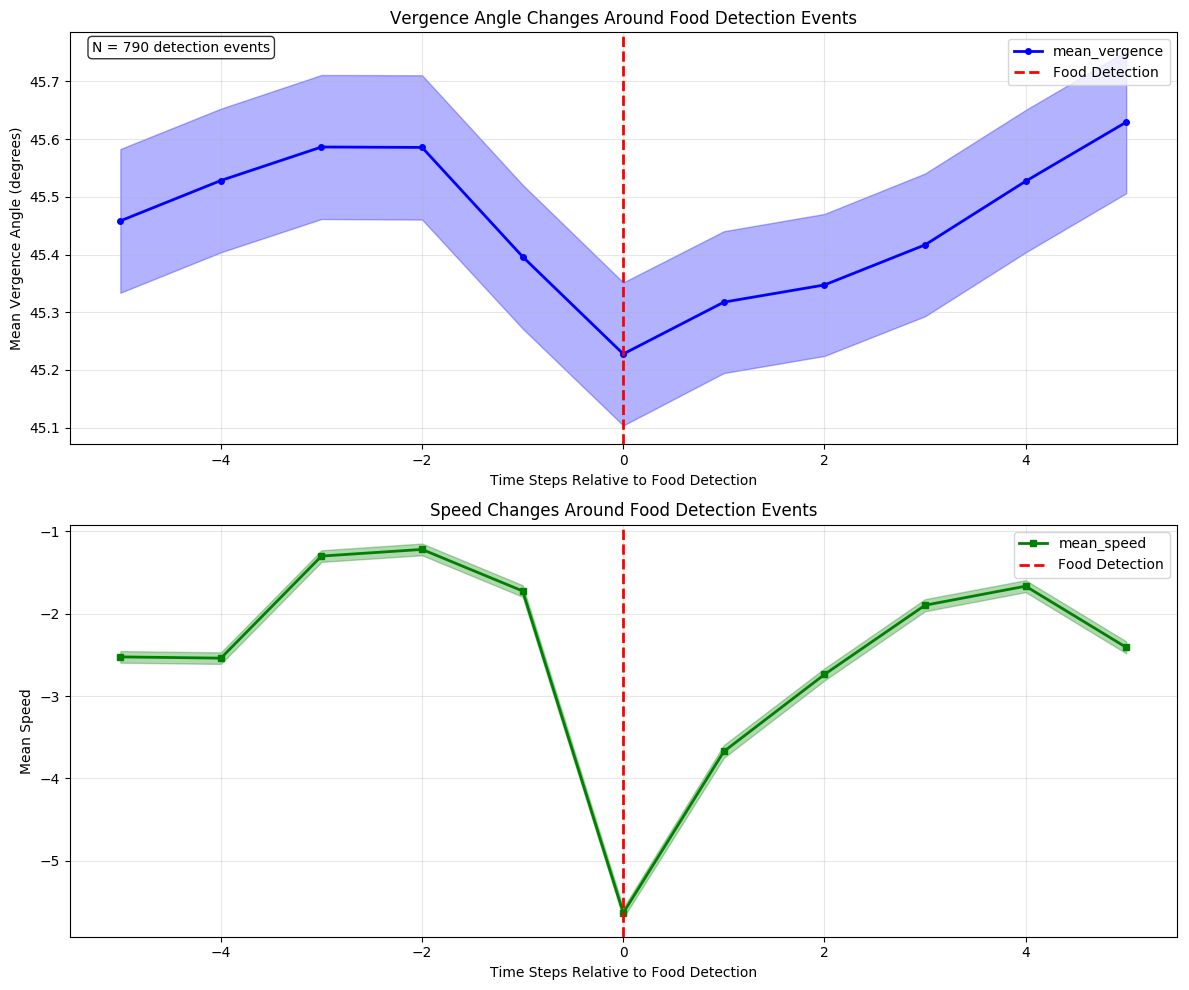

In [28]:
from utils_behavior import analyze_vergence_around_food_detection

# Perform the analysis
detection_results = analyze_vergence_around_food_detection(dff, window_size=5)

if len(detection_results) > 0:
    print(f"Analyzed {len(detection_results['detection_time_step'].unique())} food detection events")
    print(f"Total data points: {len(detection_results)}")
    
    # Calculate mean and standard error for each relative time step
    vergence_summary = detection_results.groupby('time_relative').agg({
        'vergence_angle_deg': ['mean', 'std', 'count'],
        'speed': ['mean', 'std'],
        'eating_event': 'sum'
    }).reset_index()
    
    # Flatten column names
    vergence_summary.columns = ['time_relative', 'mean_vergence', 'std_vergence', 'count', 
                               'mean_speed', 'std_speed', 'eating_events']
    vergence_summary['sem_vergence'] = vergence_summary['std_vergence'] / np.sqrt(vergence_summary['count'])
    vergence_summary['sem_speed'] = vergence_summary['std_speed'] / np.sqrt(vergence_summary['count'])
    
    # Create the visualization
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # 1. Vergence angle plot
    axes[0].plot(vergence_summary['time_relative'], vergence_summary['mean_vergence'], 
                 'b-', linewidth=2, marker='o', markersize=4)
    
    # Add error bars
    axes[0].fill_between(vergence_summary['time_relative'],
                        vergence_summary['mean_vergence'] - vergence_summary['sem_vergence'],
                        vergence_summary['mean_vergence'] + vergence_summary['sem_vergence'],
                        alpha=0.3, color='blue')
    
    # Mark the detection event
    axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Food Detection')
    
    axes[0].set_xlabel('Time Steps Relative to Food Detection')
    axes[0].set_ylabel('Mean Vergence Angle (degrees)')
    axes[0].set_title('Vergence Angle Changes Around Food Detection Events')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Add sample size information
    axes[0].text(0.02, 0.98, f'N = {len(detection_results["detection_time_step"].unique())} detection events', 
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 2. Speed plot for comparison
    axes[1].plot(vergence_summary['time_relative'], vergence_summary['mean_speed'], 
                 'g-', linewidth=2, marker='s', markersize=4)
    
    # Add error bars
    axes[1].fill_between(vergence_summary['time_relative'],
                        vergence_summary['mean_speed'] - vergence_summary['sem_speed'],
                        vergence_summary['mean_speed'] + vergence_summary['sem_speed'],
                        alpha=0.3, color='green')
    
    # Mark the detection event
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Food Detection')
    
    axes[1].set_xlabel('Time Steps Relative to Food Detection')
    axes[1].set_ylabel('Mean Speed')
    axes[1].set_title('Speed Changes Around Food Detection Events')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{results_folder}/vergence_angle_around_food_detection.png", dpi=300)
    plt.show()
else:
    print("No food detection events found in the data.")

Success trajectories: 773
Miss trajectories: 2482


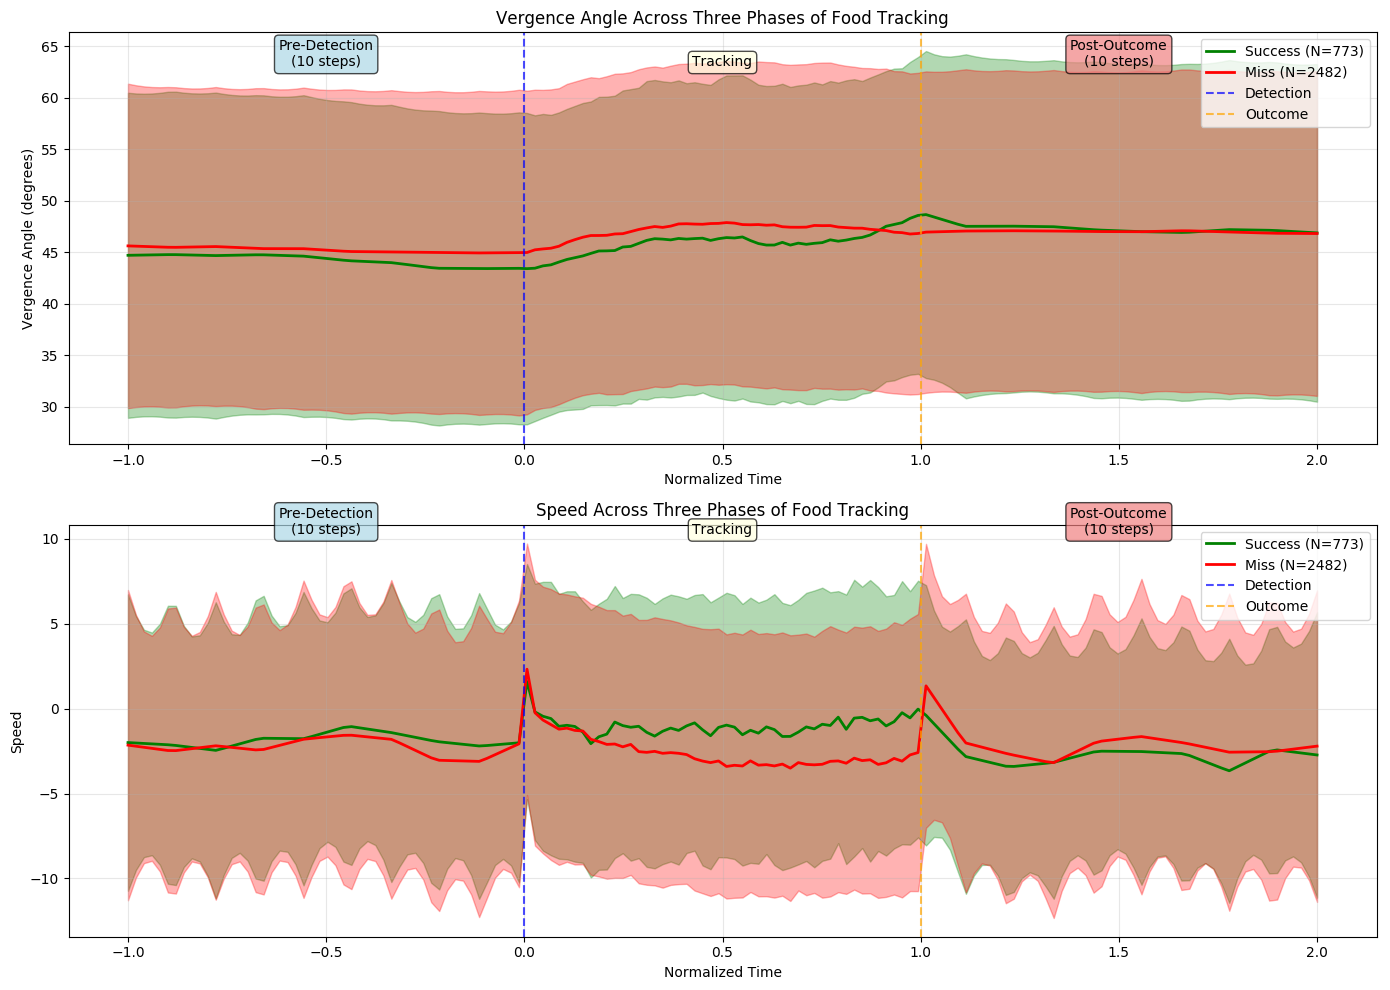

In [ ]:
from utils_behavior import analyze_vergence_speed_three_phases

# Perform the analysis
phase_duration = 10  # Duration for pre and post phases
phase_data = analyze_vergence_speed_three_phases(tracking_sequences_df, dff, phase_duration=phase_duration)

# Separate by outcome
success_phases = [d for d in phase_data if d['outcome'] == 'success']
miss_phases = [d for d in phase_data if d['outcome'] == 'miss']

print(f"Success trajectories: {len(success_phases)}")
print(f"Miss trajectories: {len(miss_phases)}")

# Create common time grid for interpolation
time_grid = np.linspace(-1, 2, 150)  # 150 points from -1 to 2

# Interpolate trajectories
def interpolate_phases(trajectories, time_grid):
    interpolated_vergence = []
    interpolated_speed = []
    
    for traj in trajectories:
        # Interpolate vergence
        vergence_interp = np.interp(time_grid, traj['time'], traj['vergence'])
        interpolated_vergence.append(vergence_interp)
        
        # Interpolate speed
        speed_interp = np.interp(time_grid, traj['time'], traj['speed'])
        interpolated_speed.append(speed_interp)
    
    return np.array(interpolated_vergence), np.array(interpolated_speed)

# Interpolate for both outcomes
success_vergence, success_speed = interpolate_phases(success_phases, time_grid)
miss_vergence, miss_speed = interpolate_phases(miss_phases, time_grid)

# Calculate means and standard errors
success_vergence_mean = np.mean(success_vergence, axis=0)
success_vergence_sem = np.std(success_vergence, axis=0) # / np.sqrt(len(success_phases))
success_speed_mean = np.mean(success_speed, axis=0)
success_speed_sem = np.std(success_speed, axis=0) # / np.sqrt(len(success_phases))

miss_vergence_mean = np.mean(miss_vergence, axis=0)
miss_vergence_sem = np.std(miss_vergence, axis=0) # / np.sqrt(len(miss_phases))
miss_speed_mean = np.mean(miss_speed, axis=0)
miss_speed_sem = np.std(miss_speed, axis=0) # / np.sqrt(len(miss_phases))

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Vergence Angle
ax1.plot(time_grid, success_vergence_mean, 'g-', linewidth=2, label=f'Success (N={len(success_phases)})')
ax1.fill_between(time_grid, 
                 success_vergence_mean - success_vergence_sem,
                 success_vergence_mean + success_vergence_sem,
                 alpha=0.3, color='green')

ax1.plot(time_grid, miss_vergence_mean, 'r-', linewidth=2, label=f'Miss (N={len(miss_phases)})')
ax1.fill_between(time_grid, 
                 miss_vergence_mean - miss_vergence_sem,
                 miss_vergence_mean + miss_vergence_sem,
                 alpha=0.3, color='red')

# Add phase boundaries
ax1.axvline(x=0, color='blue', linestyle='--', alpha=0.7, label='Detection')
ax1.axvline(x=1, color='orange', linestyle='--', alpha=0.7, label='Outcome')

# Add phase labels
ax1.text(-0.5, ax1.get_ylim()[1] * 0.95, f'Pre-Detection\n({phase_duration} steps)', ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax1.text(0.5, ax1.get_ylim()[1] * 0.95, 'Tracking', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax1.text(1.5, ax1.get_ylim()[1] * 0.95, f'Post-Outcome\n({phase_duration} steps)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

ax1.set_xlabel('Normalized Time')
ax1.set_ylabel('Vergence Angle (degrees)')
ax1.set_title('Vergence Angle Across Three Phases of Food Tracking')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Speed
ax2.plot(time_grid, success_speed_mean, 'g-', linewidth=2, label=f'Success (N={len(success_phases)})')
ax2.fill_between(time_grid, 
                 success_speed_mean - success_speed_sem,
                 success_speed_mean + success_speed_sem,
                 alpha=0.3, color='green')

ax2.plot(time_grid, miss_speed_mean, 'r-', linewidth=2, label=f'Miss (N={len(miss_phases)})')
ax2.fill_between(time_grid, 
                 miss_speed_mean - miss_speed_sem,
                 miss_speed_mean + miss_speed_sem,
                 alpha=0.3, color='red')

# Add phase boundaries
ax2.axvline(x=0, color='blue', linestyle='--', alpha=0.7, label='Detection')
ax2.axvline(x=1, color='orange', linestyle='--', alpha=0.7, label='Outcome')

# Add phase labels
ax2.text(-0.5, ax2.get_ylim()[1] * 0.95, f'Pre-Detection\n({phase_duration} steps)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax2.text(0.5, ax2.get_ylim()[1] * 0.95, 'Tracking', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax2.text(1.5, ax2.get_ylim()[1] * 0.95, f'Post-Outcome\n({phase_duration} steps)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

ax2.set_xlabel('Normalized Time')
ax2.set_ylabel('Speed')
ax2.set_title('Speed Across Three Phases of Food Tracking')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_folder}/vergence_speed_three_phases.png", dpi=300)
plt.show()

{109, 110} set()
{138, 139, 140} set()
{300} set()
{91, 92, 93, 94} set()
{162, 163, 164, 165} set()
{322, 323, 324, 325} set()
{141, 142, 143} set()
{205} set()
{232, 230, 231} set()
{320, 321, 322, 323, 324} set()
{371, 372, 373} set()
{101} set()
{112, 111} set()
{129, 130, 131} set()
{152, 153} set()
{349, 350} set()
{351} set()
{248} set()
{264, 265, 266, 263} set()
{293, 294} set()
{321} set()
{90, 91, 92} set()
{256, 257, 255} set()
{291} set()
{312, 310, 311} set()
{88, 89} set()
{185, 186, 187} set()
{242, 243, 244} set()
{274, 275} set()
{149, 150, 151, 152, 153} set()
{203, 204, 205, 206} set()
{252} set()
{266, 267} set()
{281, 282, 283} set()
{293, 294} set()
{318} set()
Analyzed 506 eating events
Total data points: 24986


/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/axes/_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/raaghav/miniforge3/envs/zfish/lib/python3.7/site-packages/matplotlib/axes/_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


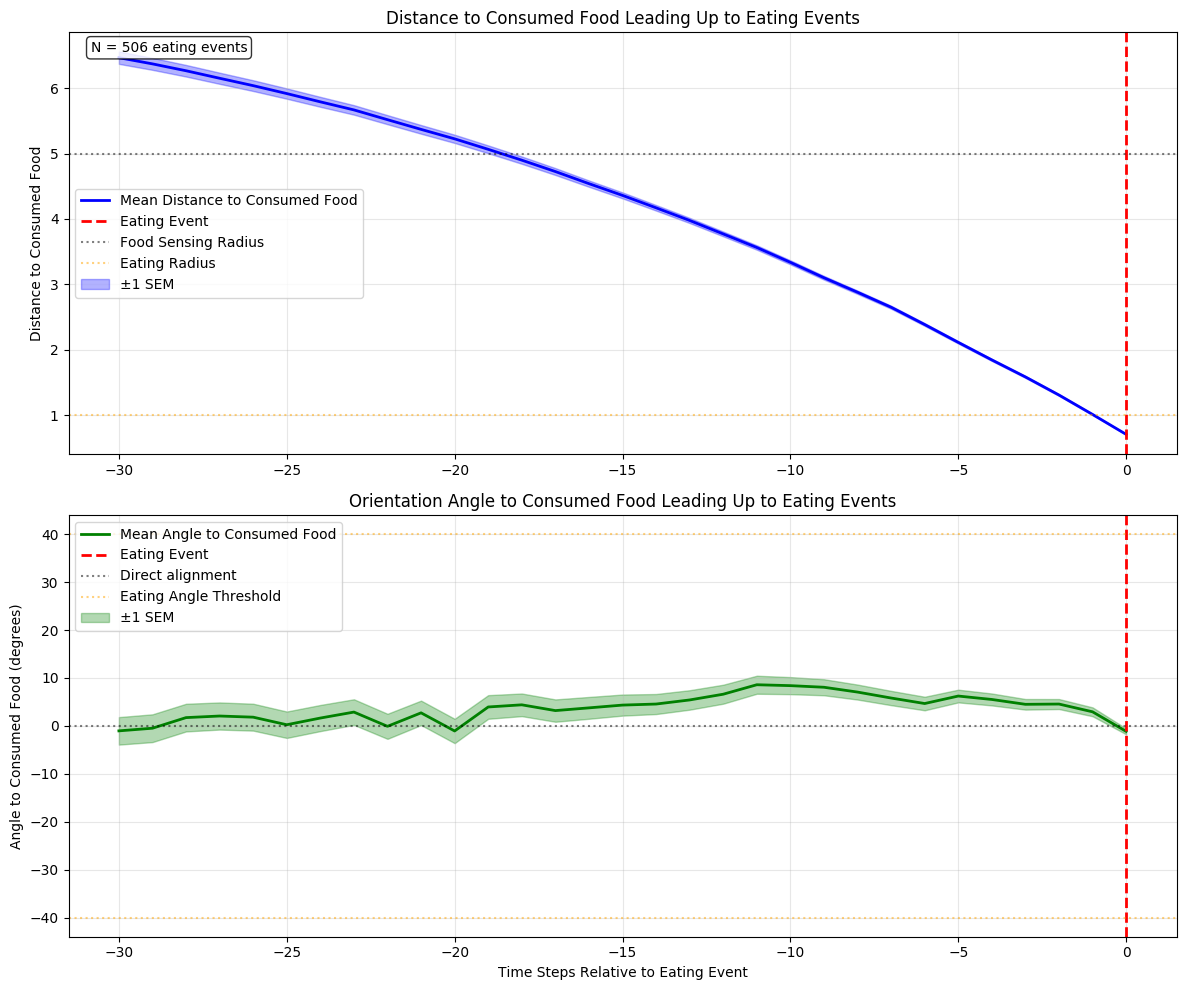

In [30]:
from utils_behavior import analyze_distance_angle_to_consumed_food

# Perform the analysis
window_size = 30
distance_angle_results = analyze_distance_angle_to_consumed_food(dff, window_size=window_size)

print(f"Analyzed {len(distance_angle_results['eating_time_step'].unique())} eating events")
print(f"Total data points: {len(distance_angle_results)}")

# Calculate mean and standard error for each relative time step
summary = distance_angle_results.groupby('time_relative').agg({
    'distance_to_consumed_food': ['mean', 'std', 'count'],
    'angle_to_consumed_food_deg': ['mean', 'std']
}).reset_index()

summary.columns = ['time_relative', 'mean_distance', 'std_distance', 'count', 'mean_angle', 'std_angle']
summary['sem_distance'] = summary['std_distance'] / np.sqrt(summary['count'])
summary['sem_angle'] = summary['std_angle'] / np.sqrt(summary['count'])

# Create visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. Distance to consumed food plot
ax1.plot(summary['time_relative'], summary['mean_distance'], 
         'b-', linewidth=2, label='Mean Distance to Consumed Food')

ax1.fill_between(summary['time_relative'],
                 summary['mean_distance'] - summary['sem_distance'],
                 summary['mean_distance'] + summary['sem_distance'],
                 alpha=0.3, color='blue', label='±1 SEM')

# Mark the eating event
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')

ax1.axhline(y=cfg.AGENT_PARAMS["food_detection_range"], color='black', linestyle=':', alpha=0.5, label='Food Sensing Radius')
ax1.axhline(y=cfg.AGENT_PARAMS["eating_radius"], color='orange', linestyle=':', alpha=0.5, label='Eating Radius')

#
ax1.set_ylabel('Distance to Consumed Food')
ax1.set_title('Distance to Consumed Food Leading Up to Eating Events')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Angle to consumed food plot
ax2.plot(summary['time_relative'], summary['mean_angle'], 
         'g-', linewidth=2, label='Mean Angle to Consumed Food')

ax2.fill_between(summary['time_relative'],
                 summary['mean_angle'] - summary['sem_angle'],
                 summary['mean_angle'] + summary['sem_angle'],
                 alpha=0.3, color='green', label='±1 SEM')

# Mark the eating event
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')

# Add horizontal line at 0 degrees for reference
ax2.axhline(y=0, color='black', linestyle=':', alpha=0.5, label='Direct alignment')

ax2.axhline(y=cfg.AGENT_PARAMS["eating_angle"]/2 * (180/np.pi), color='orange', linestyle=':', alpha=0.5, label='Eating Angle Threshold')
ax2.axhline(y=-cfg.AGENT_PARAMS["eating_angle"]/2 * (180/np.pi), color='orange', linestyle=':', alpha=0.5)

ax2.set_xlabel('Time Steps Relative to Eating Event')
ax2.set_ylabel('Angle to Consumed Food (degrees)')
ax2.set_title('Orientation Angle to Consumed Food Leading Up to Eating Events')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add text with sample information
ax1.text(0.02, 0.98, f'N = {len(distance_angle_results["eating_time_step"].unique())} eating events', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{results_folder}/distance_angle_to_consumed_food.png", dpi=300)
plt.show()

### Random Analysis

In [31]:
# def analyze_eye_food_alignment_extended(dff, window_size=25, alignment_threshold=25):
#     """
#     For each eating event, compute the angle difference between average eye angle 
#     and vector to eaten food for 50 time steps before, and check if alignment 
#     is within (-25, 25) degree range.
    
#     Parameters:
#     - window_size: Number of time steps before eating to analyze
#     - alignment_threshold: Threshold in degrees for considering alignment (±25°)
#     """
    
#     alignment_results = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event (including the eating moment)
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Calculate alignment for each time step in the window
#             for i, (_, row) in enumerate(window_data.iterrows()):
#                 # Agent position and eye angles
#                 agent_pos_t = np.array(row['position'])
#                 left_eye_angle = row['left_eye_angle']
#                 right_eye_angle = row['right_eye_angle']
                
#                 # Average eye angle (direction agent is "looking")
#                 avg_eye_angle = (left_eye_angle + right_eye_angle) / 2 + row['orientation']
#                 avg_eye_angle = np.arctan2(np.sin(avg_eye_angle), np.cos(avg_eye_angle))  # Normalize angle
                
#                 # Direction from agent to target food
#                 food_vector = target_food_pos - agent_pos_t
#                 food_direction = np.arctan2(food_vector[1], food_vector[0])
                
#                 # Calculate angular difference (directional alignment)
#                 angular_diff = food_direction - avg_eye_angle
#                 angular_diff_deg = angular_diff * 180 / np.pi
                
#                 # Check if within alignment threshold
#                 is_aligned = abs(angular_diff_deg) <= alignment_threshold
                
#                 # Store data for this time step
#                 alignment_results.append({
#                     'env_id': env_id,
#                     'episode_index': episode_index,
#                     'agent_id': agent_id,
#                     'eating_time_step': eating_row['time_step'],
#                     'time_relative': i - window_size,  # Negative values before eating, 0 at eating
#                     'angle_difference_deg': angular_diff_deg,
#                     'is_aligned': is_aligned,
#                     'distance_to_food': np.linalg.norm(food_vector)
#                 })
    
#     return pd.DataFrame(alignment_results)

# # Perform the analysis
# alignment_results = analyze_eye_food_alignment_extended(dff, window_size=25, alignment_threshold=25)

# print(f"Analyzed {len(alignment_results['eating_time_step'].unique())} eating events")
# print(f"Total data points: {len(alignment_results)}")

# # Calculate alignment statistics for each relative time step
# alignment_summary = alignment_results.groupby('time_relative').agg({
#     'is_aligned': ['mean', 'sum', 'count'],
#     'angle_difference_deg': ['mean', 'std']
# }).reset_index()

# alignment_summary.columns = ['time_relative', 'alignment_rate', 'aligned_count', 'total_count', 'mean_angle_diff', 'std_angle_diff']
# alignment_summary['alignment_percentage'] = alignment_summary['alignment_rate'] * 100

# # Create visualization
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# # 1. Alignment rate over time
# axes[0, 0].plot(alignment_summary['time_relative'], alignment_summary['alignment_percentage'], 
#                 'b-', linewidth=2, marker='o', markersize=4)
# axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# axes[0, 0].set_xlabel('Time Steps Relative to Eating Event')
# axes[0, 0].set_ylabel('Alignment Rate (%)')
# axes[0, 0].set_title('Percentage of Time Steps with Eye-Food Alignment\n(Within ±25°)')
# axes[0, 0].grid(True, alpha=0.3)
# axes[0, 0].legend()

# # 2. Mean angle difference over time
# axes[0, 1].plot(alignment_summary['time_relative'], np.abs(alignment_summary['mean_angle_diff']), 
#                 'g-', linewidth=2, marker='s', markersize=4)
# axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# axes[0, 1].axhline(y=25, color='orange', linestyle=':', linewidth=2, label='Alignment Threshold')
# axes[0, 1].set_xlabel('Time Steps Relative to Eating Event')
# axes[0, 1].set_ylabel('Mean Absolute Angle Difference (degrees)')
# axes[0, 1].set_title('Mean Absolute Eye-Food Angle Difference')
# axes[0, 1].grid(True, alpha=0.3)
# axes[0, 1].legend()

# # 3. Histogram of angle differences at eating moment (t=0)
# eating_moment_data = alignment_results[alignment_results['time_relative'] == 0]
# axes[1, 0].hist(eating_moment_data['angle_difference_deg'], bins=30, alpha=0.7, edgecolor='black')
# axes[1, 0].axvline(x=-25, color='red', linestyle='--', label='Alignment Threshold')
# axes[1, 0].axvline(x=25, color='red', linestyle='--')
# axes[1, 0].set_xlabel('Angle Difference (degrees)')
# axes[1, 0].set_ylabel('Frequency')
# axes[1, 0].set_title('Distribution of Eye-Food Angle Differences\nat Eating Moment')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # 4. Sample trajectories of angle differences
# sample_eating_events = alignment_results['eating_time_step'].unique()[:10]
# colors = plt.cm.tab10(np.linspace(0, 1, len(sample_eating_events)))

# for i, eating_time in enumerate(sample_eating_events):
#     event_data = alignment_results[alignment_results['eating_time_step'] == eating_time]
#     axes[1, 1].plot(event_data['time_relative'], event_data['angle_difference_deg'], 
#                    color=colors[i], alpha=0.6, linewidth=1)

# # Add threshold lines
# axes[1, 1].axhline(y=25, color='red', linestyle='--', linewidth=2, label='Alignment Threshold')
# axes[1, 1].axhline(y=-25, color='red', linestyle='--', linewidth=2)
# axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Eating Event')
# axes[1, 1].set_xlabel('Time Steps Relative to Eating Event')
# axes[1, 1].set_ylabel('Angle Difference (degrees)')
# axes[1, 1].set_title('Individual Eye-Food Angle Trajectories\n(Sample of 10 Eating Events)')
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print(f"\nSummary Statistics:")
# print(f"=" * 50)

# # Overall alignment rate
# overall_alignment_rate = alignment_results['is_aligned'].mean() * 100
# print(f"Overall alignment rate: {overall_alignment_rate:.1f}%")

# # Alignment rate at eating moment
# eating_moment_alignment = eating_moment_data['is_aligned'].mean() * 100
# print(f"Alignment rate at eating moment: {eating_moment_alignment:.1f}%")

# # Alignment rate 50 steps before
# start_moment_data = alignment_results[alignment_results['time_relative'] == -50]
# start_alignment = start_moment_data['is_aligned'].mean() * 100
# print(f"Alignment rate 50 steps before eating: {start_alignment:.1f}%")

# # Mean angle differences
# print(f"\nMean absolute angle differences:")
# print(f"At eating moment: {np.abs(eating_moment_data['angle_difference_deg']).mean():.1f}°")
# print(f"50 steps before: {np.abs(start_moment_data['angle_difference_deg']).mean():.1f}°")
# print(f"Overall: {np.abs(alignment_results['angle_difference_deg']).mean():.1f}°")

# # Trend analysis
# improvement_in_alignment = eating_moment_alignment - start_alignment
# print(f"\nAlignment improvement from start to eating: {improvement_in_alignment:.1f} percentage points")

# # Count of highly aligned eating events (>50% of time steps aligned)
# eating_event_alignment_rates = alignment_results.groupby('eating_time_step')['is_aligned'].mean()
# highly_aligned_events = (eating_event_alignment_rates > 0.5).sum()
# total_events = len(eating_event_alignment_rates)

# print(f"\nEating events with >50% aligned time steps: {highly_aligned_events}/{total_events} ({highly_aligned_events/total_events*100:.1f}%)")

# # Display first few rows of results
# print(f"\nSample Results (first 10 rows):")
# print(alignment_results.head(10)[['env_id', 'episode_index', 'agent_id', 'eating_time_step', 
#                                   'time_relative', 'angle_difference_deg', 'is_aligned']])

In [32]:
# def analyze_orientation_food_alignment_extended(dff, window_size=25, alignment_threshold=25):
#     """
#     For each eating event, compute the angle difference between agent orientation
#     and vector to eaten food for 50 time steps before, and check if alignment 
#     is within (-25, 25) degree range.
    
#     Parameters:
#     - window_size: Number of time steps before eating to analyze
#     - alignment_threshold: Threshold in degrees for considering alignment (±25°)
#     """
    
#     alignment_results = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event (including the eating moment)
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Calculate alignment for each time step in the window
#             for i, (_, row) in enumerate(window_data.iterrows()):
#                 # Agent position and eye angles
#                 agent_pos_t = np.array(row['position'])
                
#                 # Average eye angle (direction agent is "looking")
#                 orientation_angle = row['orientation']
#                 orientation_angle = np.arctan2(np.sin(orientation_angle), np.cos(orientation_angle))  # Normalize angle

#                 # Direction from agent to target food
#                 food_vector = target_food_pos - agent_pos_t
#                 food_direction = np.arctan2(food_vector[1], food_vector[0])
                
#                 # Calculate angular difference (directional alignment)
#                 angular_diff = food_direction - orientation_angle
#                 angular_diff_deg = angular_diff * 180 / np.pi
                
#                 # Check if within alignment threshold
#                 is_aligned = abs(angular_diff_deg) <= alignment_threshold
                
#                 # Store data for this time step
#                 alignment_results.append({
#                     'env_id': env_id,
#                     'episode_index': episode_index,
#                     'agent_id': agent_id,
#                     'eating_time_step': eating_row['time_step'],
#                     'time_relative': i - window_size,  # Negative values before eating, 0 at eating
#                     'angle_difference_deg': angular_diff_deg,
#                     'is_aligned': is_aligned,
#                     'distance_to_food': np.linalg.norm(food_vector)
#                 })
    
#     return pd.DataFrame(alignment_results)

# # Perform the analysis
# window_size = 25
# alignment_results = analyze_orientation_food_alignment_extended(dff, window_size=window_size, alignment_threshold=25)

# print(f"Analyzed {len(alignment_results['eating_time_step'].unique())} eating events")
# print(f"Total data points: {len(alignment_results)}")

# # Calculate alignment statistics for each relative time step
# alignment_summary = alignment_results.groupby('time_relative').agg({
#     'is_aligned': ['mean', 'sum', 'count'],
#     'angle_difference_deg': ['mean', 'std']
# }).reset_index()

# alignment_summary.columns = ['time_relative', 'alignment_rate', 'aligned_count', 'total_count', 'mean_angle_diff', 'std_angle_diff']
# alignment_summary['alignment_percentage'] = alignment_summary['alignment_rate'] * 100

# # Create visualization
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# # 1. Alignment rate over time
# axes[0, 0].plot(alignment_summary['time_relative'], alignment_summary['alignment_percentage'], 
#                 'b-', linewidth=2, marker='o', markersize=4)
# axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# axes[0, 0].set_xlabel('Time Steps Relative to Eating Event')
# axes[0, 0].set_ylabel('Alignment Rate (%)')
# axes[0, 0].set_title('Percentage of Time Steps with Orientation-Food Alignment\n(Within ±25°)')
# axes[0, 0].grid(True, alpha=0.3)
# axes[0, 0].legend()

# # 2. Mean angle difference over time
# axes[0, 1].plot(alignment_summary['time_relative'], np.abs(alignment_summary['mean_angle_diff']), 
#                 'g-', linewidth=2, marker='s', markersize=4)
# axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# axes[0, 1].axhline(y=25, color='orange', linestyle=':', linewidth=2, label='Alignment Threshold')
# axes[0, 1].set_xlabel('Time Steps Relative to Eating Event')
# axes[0, 1].set_ylabel('Mean Absolute Angle Difference (degrees)')
# axes[0, 1].set_title('Mean Absolute Orientation-Food Angle Difference')
# axes[0, 1].grid(True, alpha=0.3)
# axes[0, 1].legend()

# # 3. Histogram of angle differences at eating moment (t=0)
# eating_moment_data = alignment_results[alignment_results['time_relative'] == 0]
# axes[1, 0].hist(eating_moment_data['angle_difference_deg'], bins=30, alpha=0.7, edgecolor='black')
# axes[1, 0].axvline(x=-25, color='red', linestyle='--', label='Alignment Threshold')
# axes[1, 0].axvline(x=25, color='red', linestyle='--')
# axes[1, 0].set_xlabel('Angle Difference (degrees)')
# axes[1, 0].set_ylabel('Frequency')
# axes[1, 0].set_title('Distribution of Orientation-Food Angle Differences\nat Eating Moment')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # 4. Sample trajectories of angle differences
# sample_eating_events = alignment_results['eating_time_step'].unique()[:10]
# colors = plt.cm.tab10(np.linspace(0, 1, len(sample_eating_events)))

# for i, eating_time in enumerate(sample_eating_events):
#     event_data = alignment_results[alignment_results['eating_time_step'] == eating_time]
#     axes[1, 1].plot(event_data['time_relative'], event_data['angle_difference_deg'], 
#                    color=colors[i], alpha=0.6, linewidth=1)

# # Add threshold lines
# axes[1, 1].axhline(y=25, color='red', linestyle='--', linewidth=2, label='Alignment Threshold')
# axes[1, 1].axhline(y=-25, color='red', linestyle='--', linewidth=2)
# axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Eating Event')
# axes[1, 1].set_xlabel('Time Steps Relative to Eating Event')
# axes[1, 1].set_ylabel('Angle Difference (degrees)')
# axes[1, 1].set_title('Individual Orientation-Food Angle Trajectories\n(Sample of 10 Eating Events)')
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print(f"\nSummary Statistics:")
# print(f"=" * 50)

# # Overall alignment rate
# overall_alignment_rate = alignment_results['is_aligned'].mean() * 100
# print(f"Overall alignment rate: {overall_alignment_rate:.1f}%")

# # Alignment rate at eating moment
# eating_moment_alignment = eating_moment_data['is_aligned'].mean() * 100
# print(f"Alignment rate at eating moment: {eating_moment_alignment:.1f}%")

# # Alignment rate 50 steps before
# start_moment_data = alignment_results[alignment_results['time_relative'] == -window_size]
# start_alignment = start_moment_data['is_aligned'].mean() * 100
# print(f"Alignment rate 50 steps before eating: {start_alignment:.1f}%")

# # Mean angle differences
# print(f"\nMean absolute angle differences:")
# print(f"At eating moment: {np.abs(eating_moment_data['angle_difference_deg']).mean():.1f}°")
# print(f"50 steps before: {np.abs(start_moment_data['angle_difference_deg']).mean():.1f}°")
# print(f"Overall: {np.abs(alignment_results['angle_difference_deg']).mean():.1f}°")

# # Trend analysis
# improvement_in_alignment = eating_moment_alignment - start_alignment
# print(f"\nAlignment improvement from start to eating: {improvement_in_alignment:.1f} percentage points")

# # Count of highly aligned eating events (>50% of time steps aligned)
# eating_event_alignment_rates = alignment_results.groupby('eating_time_step')['is_aligned'].mean()
# highly_aligned_events = (eating_event_alignment_rates > 0.5).sum()
# total_events = len(eating_event_alignment_rates)

# print(f"\nEating events with >50% aligned time steps: {highly_aligned_events}/{total_events} ({highly_aligned_events/total_events*100:.1f}%)")

# # Display first few rows of results
# print(f"\nSample Results (first 10 rows):")
# print(alignment_results.head(10)[['env_id', 'episode_index', 'agent_id', 'eating_time_step', 
#                                   'time_relative', 'angle_difference_deg', 'is_aligned']])

In [33]:
# def analyze_distance_to_eaten_food(dff, window_size=50):
#     """
#     For each eating event, analyze the distance to the food being eaten 
#     for a specified number of time steps before the eating event.
#     """
    
#     distance_data = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event (including the eating moment)
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Calculate distance to target food for each time step in the window
#             for i, (_, row) in enumerate(window_data.iterrows()):
#                 agent_pos_t = np.array(row['position'])
#                 distance_to_target = np.linalg.norm(target_food_pos - agent_pos_t)
                
#                 distance_data.append({
#                     'env_id': env_id,
#                     'episode_index': episode_index,
#                     'agent_id': agent_id,
#                     'eating_time_step': eating_row['time_step'],
#                     'time_relative': i - window_size,  # Negative values before eating, 0 at eating
#                     'distance_to_eaten_food': distance_to_target
#                 })
    
#     return pd.DataFrame(distance_data)

# # Perform the analysis
# distance_results = analyze_distance_to_eaten_food(dff, window_size=50)

# print(f"Analyzed {len(distance_results['eating_time_step'].unique())} eating events")
# print(f"Total data points: {len(distance_results)}")

# # Calculate mean and standard error for each relative time step
# distance_summary = distance_results.groupby('time_relative').agg({
#     'distance_to_eaten_food': ['mean', 'std', 'count']
# }).reset_index()

# distance_summary.columns = ['time_relative', 'mean_distance', 'std_distance', 'count']
# distance_summary['sem_distance'] = distance_summary['std_distance'] / np.sqrt(distance_summary['count'])

# # Create the main plot
# plt.figure(figsize=(12, 8))

# # Plot mean distance with error region
# plt.plot(distance_summary['time_relative'], distance_summary['mean_distance'], 
#          'b-', linewidth=2, label='Mean Distance to Eaten Food')

# plt.fill_between(distance_summary['time_relative'],
#                 distance_summary['mean_distance'] - distance_summary['sem_distance'],
#                 distance_summary['mean_distance'] + distance_summary['sem_distance'],
#                 alpha=0.3, color='blue', label='±1 SEM')

# # Mark the eating event
# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')

# # Add labels and formatting
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Distance to Eaten Food')
# plt.title('Distance to Eaten Food Leading Up to Eating Events')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Add text with sample information
# plt.text(0.02, 0.98, f'N = {len(distance_results["eating_time_step"].unique())} eating events', 
#          transform=plt.gca().transAxes, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print(f"\nDistance Analysis:")
# print(f"Mean distance at eating moment (t=0): {distance_summary[distance_summary['time_relative']==0]['mean_distance'].iloc[0]:.2f} ± {distance_summary[distance_summary['time_relative']==0]['sem_distance'].iloc[0]:.2f}")
# print(f"Mean distance 50 steps before: {distance_summary[distance_summary['time_relative']==-50]['mean_distance'].iloc[0]:.2f} ± {distance_summary[distance_summary['time_relative']==-50]['sem_distance'].iloc[0]:.2f}")

# # Calculate distance reduction
# initial_distance = distance_summary[distance_summary['time_relative']==-50]['mean_distance'].iloc[0]
# final_distance = distance_summary[distance_summary['time_relative']==0]['mean_distance'].iloc[0]
# distance_reduction = initial_distance - final_distance

# print(f"Distance reduction: {distance_reduction:.2f} units")
# print(f"Percentage reduction: {(distance_reduction/initial_distance)*100:.1f}%")

# # Additional plot: Individual trajectories
# plt.figure(figsize=(12, 6))

# # Plot a sample of individual distance trajectories
# sample_eating_events = distance_results['eating_time_step'].unique()[:10]  # Show first 10 eating events
# colors = plt.cm.tab10(np.linspace(0, 1, len(sample_eating_events)))

# for i, eating_time in enumerate(sample_eating_events):
#     event_data = distance_results[distance_results['eating_time_step'] == eating_time]
#     plt.plot(event_data['time_relative'], event_data['distance_to_eaten_food'], 
#             color=colors[i], alpha=0.6, linewidth=1)

# # Overlay the mean
# plt.plot(distance_summary['time_relative'], distance_summary['mean_distance'], 
#          'k-', linewidth=3, label='Mean Distance')

# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Distance to Eaten Food')
# plt.title('Individual Distance Trajectories (Sample of 10 Eating Events)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Analysis of pursuit behavior based on distance decrease
# print(f"\nPursuit Behavior Analysis:")
# print("=" * 40)

# # Calculate the proportion of time steps where distance is decreasing
# for eating_time in distance_results['eating_time_step'].unique()[:5]:  # Show first 5 events
#     event_data = distance_results[distance_results['eating_time_step'] == eating_time].sort_values('time_relative')
#     distances = event_data['distance_to_eaten_food'].values
    
#     # Calculate changes in distance
#     distance_changes = np.diff(distances)
#     decreasing_steps = np.sum(distance_changes < 0)
#     total_steps = len(distance_changes)
    
#     print(f"Eating event at time {eating_time}:")
#     print(f"  Steps with decreasing distance: {decreasing_steps}/{total_steps} ({decreasing_steps/total_steps*100:.1f}%)")
#     print(f"  Initial distance: {distances[0]:.2f}")
#     print(f"  Final distance: {distances[-1]:.2f}")
#     print(f"  Total reduction: {distances[0] - distances[-1]:.2f}")
#     print()

In [34]:
# def analyze_target_lock_to_eaten_food(dff, window_size=50):
#     """
#     For each eating event, analyze the target lock, defined as the max(h * d)/(sum h * d)
#     for a specified number of time steps before the eating event.
#     """
    
#     target_lock_data = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event (including the eating moment)
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Calculate distance to target food for each time step in the window
#             for i, (_, row) in enumerate(window_data.iterrows()):
#                 agent_pos_t = np.array(row['position'])
#                 distance_to_target = np.linalg.norm(target_food_pos - agent_pos_t)

#                 # Calculate target lock
#                 # h is the heading unit vector of the agent, and d is the unit vector to the target food
#                 heading_vector = np.array([np.cos(row['orientation']), np.sin(row['orientation'])])
#                 target_vector = target_food_pos - agent_pos_t
#                 target_vector /= np.linalg.norm(target_vector)  # Normalize to unit vector
#                 h_dot_d = np.dot(heading_vector, target_vector)  # Dot product

#                 # Calculate distances to all food items
#                 food_positions_t = np.array(row['food_positions'])
#                 distances_to_all_foods = np.linalg.norm(food_positions_t - agent_pos_t, axis=1)
                
#                 perception_radius = 20  # Adjust this value as needed
#                 nearby_food_mask = distances_to_all_foods <= perception_radius
                
#                 if np.sum(nearby_food_mask) == 0:
#                     target_lock = 0
#                 else:
#                     # Calculate h dot d for all nearby food items
#                     h_dot_d_all = []
#                     for food_pos in food_positions_t[nearby_food_mask]:
#                         food_vector = food_pos - agent_pos_t
#                         food_vector_norm = food_vector / np.linalg.norm(food_vector)
#                         h_dot_d_food = np.dot(heading_vector, food_vector_norm)
#                         h_dot_d_all.append(h_dot_d_food)
                    
#                     # Calculate target lock as h_dot_d divided by sum of all h_dot_d values
#                     sum_h_dot_d = np.sum(h_dot_d_all)
#                     if sum_h_dot_d == 0:
#                         target_lock = 0
#                     else:
#                         target_lock = h_dot_d / sum_h_dot_d

#                 target_lock_data.append({
#                     'env_id': env_id,
#                     'episode_index': episode_index,
#                     'agent_id': agent_id,
#                     'eating_time_step': eating_row['time_step'],
#                     'time_relative': i - window_size,  # Negative values before eating, 0 at eating
#                     'target_lock': target_lock
#                 })
    
#     return pd.DataFrame(target_lock_data)

# # Perform the analysis
# target_lock_results = analyze_target_lock_to_eaten_food(dff, window_size=50)

# print(f"Analyzed {len(target_lock_results['eating_time_step'].unique())} eating events")
# print(f"Total data points: {len(target_lock_results)}")

# # Calculate mean and standard error for each relative time step
# target_lock_summary = target_lock_results.groupby('time_relative').agg({
#     'target_lock': ['mean', 'std', 'count']
# }).reset_index()

# target_lock_summary.columns = ['time_relative', 'mean_target_lock', 'std_target_lock', 'count']
# target_lock_summary['sem_target_lock'] = target_lock_summary['std_target_lock'] / np.sqrt(target_lock_summary['count'])

# # Create the main plot
# plt.figure(figsize=(12, 8))

# # Plot mean target lock with error region
# plt.plot(target_lock_summary['time_relative'], target_lock_summary['mean_target_lock'], 
#          'b-', linewidth=2, label='Mean Target Lock')

# plt.fill_between(target_lock_summary['time_relative'],
#                 target_lock_summary['mean_target_lock'] - target_lock_summary['sem_target_lock'],
#                 target_lock_summary['mean_target_lock'] + target_lock_summary['sem_target_lock'],
#                 alpha=0.3, color='blue', label='±1 SEM')

# # Mark the eating event
# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')

# # Add labels and formatting
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Target Lock')
# plt.title('Target Lock Leading Up to Eating Events')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Add text with sample information
# plt.text(0.02, 0.98, f'N = {len(target_lock_results["eating_time_step"].unique())} eating events', 
#          transform=plt.gca().transAxes, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print(f"\nTarget Lock Analysis:")
# print(f"Mean target lock at eating moment (t=0): {target_lock_summary[target_lock_summary['time_relative']==0]['mean_target_lock'].iloc[0]:.2f} ± {target_lock_summary[target_lock_summary['time_relative']==0]['sem_target_lock'].iloc[0]:.2f}")
# print(f"Mean target lock 50 steps before: {target_lock_summary[target_lock_summary['time_relative']==-50]['mean_target_lock'].iloc[0]:.2f} ± {target_lock_summary[target_lock_summary['time_relative']==-50]['sem_target_lock'].iloc[0]:.2f}")

# # Calculate target lock reduction
# initial_target_lock = target_lock_summary[target_lock_summary['time_relative']==-50]['mean_target_lock'].iloc[0]
# final_target_lock = target_lock_summary[target_lock_summary['time_relative']==0]['mean_target_lock'].iloc[0]
# target_lock_reduction = initial_target_lock - final_target_lock

# print(f"Target lock reduction: {target_lock_reduction:.2f} units")
# print(f"Percentage reduction: {(target_lock_reduction/initial_target_lock)*100:.1f}%")

# # Additional plot: Individual trajectories
# plt.figure(figsize=(12, 6))

# # Plot a sample of individual target lock trajectories
# sample_eating_events = target_lock_results['eating_time_step'].unique()[:10]  # Show first 10 eating events
# colors = plt.cm.tab10(np.linspace(0, 1, len(sample_eating_events)))

# for i, eating_time in enumerate(sample_eating_events):
#     event_data = target_lock_results[target_lock_results['eating_time_step'] == eating_time]
#     plt.plot(event_data['time_relative'], event_data['target_lock'], 
#             color=colors[i], alpha=0.6, linewidth=1)

# # Overlay the mean target lock
# plt.plot(target_lock_summary['time_relative'], target_lock_summary['mean_target_lock'], 
#          'k-', linewidth=3, label='Mean Target Lock')

# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Target Lock')
# plt.title('Individual Target Lock Trajectories (Sample of 10 Eating Events)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Analysis of pursuit behavior based on target lock decrease
# print(f"\nPursuit Behavior Analysis:")
# print("=" * 40)

# # Calculate the proportion of time steps where target lock is decreasing
# for eating_time in target_lock_results['eating_time_step'].unique()[:5]:  # Show first 5 events
#     event_data = target_lock_results[target_lock_results['eating_time_step'] == eating_time].sort_values('time_relative')
#     target_locks = event_data['target_lock'].values

#     # Calculate changes in target lock
#     target_lock_changes = np.diff(target_locks)
#     decreasing_steps = np.sum(target_lock_changes < 0)
#     total_steps = len(target_lock_changes)
    
#     print(f"Eating event at time {eating_time}:")
#     print(f"  Steps with decreasing target lock: {decreasing_steps}/{total_steps} ({decreasing_steps/total_steps*100:.1f}%)")
#     print(f"  Initial target lock: {target_locks[0]:.2f}")
#     print(f"  Final target lock: {target_locks[-1]:.2f}")
#     print(f"  Total reduction: {target_locks[0] - target_locks[-1]:.2f}")
#     print()

In [35]:
# from scipy.stats import mannwhitneyu

# def analyze_eating_pursuit_behavior(dff, window_size=10, angle_threshold=0.2, distance_tolerance=0.1):
#     """
#     Analyze whether eating events are preceded by hunting pursuit behavior.
    
#     Parameters:
#     - window_size: Number of time steps before eating to analyze
#     - angle_threshold: Maximum deviation from target angle (radians)
#     - distance_tolerance: Tolerance for "strictly decreasing" distance
#     """
    
#     results = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Analyze pursuit behavior
#             pursuit_metrics = analyze_window_pursuit(window_data, target_food_pos, target_food_idx, 
#                                                    angle_threshold, distance_tolerance)
            
#             results.append({
#                 'env_id': env_id,
#                 'episode_index': episode_index,
#                 'agent_id': agent_id,
#                 'eating_time_step': eating_row['time_step'],
#                 'target_food_idx': target_food_idx,
#                 'final_distance': distances_to_foods[target_food_idx],
#                 **pursuit_metrics
#             })
    
#     return pd.DataFrame(results)

# def analyze_window_pursuit(window_data, target_food_pos, target_food_idx, angle_threshold, distance_tolerance):
#     """Analyze pursuit behavior in a time window."""
    
#     # Calculate angles to target food for each time step
#     angles_to_target = []
#     distances_to_target = []
#     eye_angle_to_target = []
#     target_consistency = []
    
#     for _, row in window_data.iterrows():
#         agent_pos = np.array(row['position'])
#         agent_orientation = row['orientation']
#         food_positions = np.array(row['food_positions'])
        
#         # Calculate angle to target food
#         target_vector = target_food_pos - agent_pos
#         target_angle = np.arctan2(target_vector[1], target_vector[0])
        
#         # Normalize angle difference
#         angle_diff = target_angle - agent_orientation
#         angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
#         angles_to_target.append(angle_diff)
        
#         # Calculate distance to target
#         distance_to_target = np.linalg.norm(target_vector)
#         distances_to_target.append(distance_to_target)
        
#         # Check eye angle alignment with target
#         left_eye_angle = row['left_eye_angle']
#         right_eye_angle = row['right_eye_angle']
        
#         eye_angle = (left_eye_angle + right_eye_angle) / 2
#         eye_angle_diff = eye_angle - target_angle
#         eye_angle_diff = np.arctan2(np.sin(eye_angle_diff), np.cos(eye_angle_diff))
#         eye_angle_to_target.append(eye_angle_diff)
        
#         # Check target consistency (is this food still the closest?)
#         current_distances = np.linalg.norm(food_positions - agent_pos, axis=1)
#         current_closest_idx = np.argmin(current_distances)
#         target_consistency.append(current_closest_idx == target_food_idx)
    
#     # Calculate metrics
#     angles_to_target = np.array(angles_to_target)
#     distances_to_target = np.array(distances_to_target)

#     print(eye_angle_to_target)
    
#     # 1. Eye angle alignment score
#     eye_angle_to_target = np.mean(eye_angle_to_target)

#     # 2. Distance decreasing score
#     distance_differences = np.diff(distances_to_target)
#     decreasing_count = np.sum(distance_differences < distance_tolerance)
#     distance_decreasing_score = decreasing_count / len(distance_differences) if len(distance_differences) > 0 else 0
    
#     # 3. Target consistency score
#     target_consistency_score = np.mean(target_consistency)
    
#     # 4. Average distance to target during window
#     avg_distance = np.mean(distances_to_target)
    
#     # 5. Heading alignment score (how well is agent oriented towards target)
#     avg_heading_alignment = np.mean(np.abs(angles_to_target))
    
#     return {
#         'eye_alignment_score': np.abs(eye_angle_to_target * 180/np.pi),  # Convert to degrees
#         'distance_decreasing_score': distance_decreasing_score,
#         'target_consistency_score': target_consistency_score,
#         'avg_distance_to_target': avg_distance,
#         'avg_heading_misalignment': avg_heading_alignment,
#         'initial_distance': distances_to_target[0],
#         'distance_reduction': distances_to_target[0] - distances_to_target[-1]
#     }

# # Perform the analysis
# pursuit_results = analyze_eating_pursuit_behavior(dff, window_size=10)

# print("Eating Pursuit Analysis Results:")
# print("=" * 50)
# print(f"Total eating events analyzed: {len(pursuit_results)}")

# # Summary statistics
# print(f"\nPursuit Behavior Metrics (mean ± std):")
# print(f"Eye alignment score: {pursuit_results['eye_alignment_score'].mean():.3f} ± {pursuit_results['eye_alignment_score'].std():.3f}")
# print(f"Distance decreasing score: {pursuit_results['distance_decreasing_score'].mean():.3f} ± {pursuit_results['distance_decreasing_score'].std():.3f}")
# print(f"Target consistency score: {pursuit_results['target_consistency_score'].mean():.3f} ± {pursuit_results['target_consistency_score'].std():.3f}")
# print(f"Average distance to target: {pursuit_results['avg_distance_to_target'].mean():.3f} ± {pursuit_results['avg_distance_to_target'].std():.3f}")
# print(f"Average heading misalignment: {pursuit_results['avg_heading_misalignment'].mean():.3f} ± {pursuit_results['avg_heading_misalignment'].std():.3f}")

# # Classify eating events as "pursuit" or "opportunistic"
# # Define thresholds for pursuit behavior
# eye_threshold = 20
# distance_threshold = 0.5  # At least 50% decreasing distance
# consistency_threshold = 0.7  # At least 70% target consistency

# pursuit_results['is_pursuit'] = (
#     (pursuit_results['eye_alignment_score'] >= eye_threshold) &
#     (pursuit_results['distance_decreasing_score'] >= distance_threshold) &
#     (pursuit_results['target_consistency_score'] >= consistency_threshold)
# )

# pursuit_count = pursuit_results['is_pursuit'].sum()
# opportunistic_count = len(pursuit_results) - pursuit_count

# print(f"\nClassification Results:")
# print(f"Pursuit eating events: {pursuit_count} ({pursuit_count/len(pursuit_results)*100:.1f}%)")
# print(f"Opportunistic eating events: {opportunistic_count} ({opportunistic_count/len(pursuit_results)*100:.1f}%)")

# # Create visualizations
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # 1. Eye alignment score distribution
# axes[0, 0].hist(pursuit_results['eye_alignment_score'], bins=20, alpha=0.7, edgecolor='black')
# axes[0, 0].axvline(eye_threshold, color='red', linestyle='--', label=f'Threshold ({eye_threshold})')
# axes[0, 0].set_xlabel('Eye Angle to Target (degrees)')
# axes[0, 0].set_ylabel('Frequency')
# axes[0, 0].set_title('Eye Alignment with Target')
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # 2. Distance decreasing score distribution
# axes[0, 1].hist(pursuit_results['distance_decreasing_score'], bins=20, alpha=0.7, edgecolor='black')
# axes[0, 1].axvline(distance_threshold, color='red', linestyle='--', label=f'Threshold ({distance_threshold})')
# axes[0, 1].set_xlabel('Distance Decreasing Score')
# axes[0, 1].set_ylabel('Frequency')
# axes[0, 1].set_title('Distance Decreasing Behavior')
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# # 3. Target consistency score distribution
# axes[0, 2].hist(pursuit_results['target_consistency_score'], bins=20, alpha=0.7, edgecolor='black')
# axes[0, 2].axvline(consistency_threshold, color='red', linestyle='--', label=f'Threshold ({consistency_threshold})')
# axes[0, 2].set_xlabel('Target Consistency Score')
# axes[0, 2].set_ylabel('Frequency')
# axes[0, 2].set_title('Target Consistency')
# axes[0, 2].legend()
# axes[0, 2].grid(True, alpha=0.3)

# # 4. Distance reduction vs final distance
# pursuit_data = pursuit_results[pursuit_results['is_pursuit']]
# opportunistic_data = pursuit_results[~pursuit_results['is_pursuit']]

# axes[1, 0].scatter(pursuit_data['final_distance'], pursuit_data['distance_reduction'], 
#                   alpha=0.6, label='Pursuit', color='green')
# axes[1, 0].scatter(opportunistic_data['final_distance'], opportunistic_data['distance_reduction'], 
#                   alpha=0.6, label='Opportunistic', color='orange')
# axes[1, 0].set_xlabel('Final Distance to Target')
# axes[1, 0].set_ylabel('Distance Reduction')
# axes[1, 0].set_title('Distance Reduction vs Final Distance')
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # 5. Heading alignment comparison
# pursuit_heading = pursuit_data['avg_heading_misalignment']
# opportunistic_heading = opportunistic_data['avg_heading_misalignment']

# axes[1, 1].boxplot([pursuit_heading, opportunistic_heading], 
#                    labels=['Pursuit', 'Opportunistic'])
# axes[1, 1].set_ylabel('Average Heading Misalignment (radians)')
# axes[1, 1].set_title('Heading Alignment Comparison')
# axes[1, 1].grid(True, alpha=0.3)

# # 6. Pursuit classification pie chart
# axes[1, 2].pie([pursuit_count, opportunistic_count], 
#                labels=['Pursuit', 'Opportunistic'],
#                colors=['green', 'orange'],
#                autopct='%1.1f%%')
# axes[1, 2].set_title('Eating Event Classification')

# plt.tight_layout()
# plt.show()

# # Print detailed results for first few eating events
# print(f"\nDetailed Results (first 5 eating events):")
# print("=" * 80)
# for i, row in pursuit_results.head().iterrows():
#     print(f"Event {i+1}: Env {row['env_id']}, Episode {row['episode_index']}, Agent {row['agent_id']}")
#     print(f"  Time step: {row['eating_time_step']}")
#     print(f"  Eye alignment: {row['eye_alignment_score']:.3f}")
#     print(f"  Distance decreasing: {row['distance_decreasing_score']:.3f}")
#     print(f"  Target consistency: {row['target_consistency_score']:.3f}")
#     print(f"  Classification: {'Pursuit' if row['is_pursuit'] else 'Opportunistic'}")
#     print()

# # Statistical comparison between pursuit and opportunistic

# if len(pursuit_data) > 0 and len(opportunistic_data) > 0:
#     print("Statistical Comparison (Mann-Whitney U test):")
#     print("=" * 50)
    
#     # Compare final distances
#     stat, p_val = mannwhitneyu(pursuit_data['final_distance'], opportunistic_data['final_distance'])
#     print(f"Final distance: p-value = {p_val:.4f}")
    
#     # Compare distance reduction
#     stat, p_val = mannwhitneyu(pursuit_data['distance_reduction'], opportunistic_data['distance_reduction'])
#     print(f"Distance reduction: p-value = {p_val:.4f}")
    
#     # Compare heading alignment
#     stat, p_val = mannwhitneyu(pursuit_data['avg_heading_misalignment'], opportunistic_data['avg_heading_misalignment'])
#     print(f"Heading misalignment: p-value = {p_val:.4f}")

In [36]:
# # Plot eye positions before the first eating event for each agent (single environment only)
# fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# # Filter for a single environment (env_id = 0)
# single_env_data = dff[dff['env_id'] == 0]
# agents = single_env_data['agent_id'].unique()
# window_size = 20  # Number of time steps before eating to show
# colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# for agent_idx, agent_id in enumerate(agents):
#        agent_data = single_env_data[single_env_data['agent_id'] == agent_id].sort_values('time_step').reset_index(drop=True)
       
#        # Find the first eating event for this agent
#        first_eating_events = agent_data[agent_data['eating_event']]
       
#        if len(first_eating_events) > 0:
#               first_eating_idx = first_eating_events.index[0]
              
#               # Get window before first eating event
#               start_idx = max(0, first_eating_idx - window_size)
#               window_data = agent_data.iloc[start_idx:first_eating_idx + 1]
              
#               color = colors[agent_idx % len(colors)]
              
#               # Plot left and right eye angles over time
#               ax.plot(window_data['time_step'], window_data['left_eye_angle'], 
#                         color=color, linestyle='-', linewidth=2, alpha=0.8,
#                         label=f'Agent {agent_id} Left Eye')
#               ax.plot(window_data['time_step'], window_data['right_eye_angle'], 
#                         color=color, linestyle='--', linewidth=2, alpha=0.8,
#                         label=f'Agent {agent_id} Right Eye')
              
#               # Mark the eating event
#               eating_time = first_eating_events.iloc[0]['time_step']
#               ax.axvline(x=eating_time, color=color, linestyle=':', 
#                               linewidth=2, alpha=0.7)
              
#               # Print some info
#               print(f"Agent {agent_id}: First eating at time step {eating_time}")
#               print(f"  Left eye angle at eating: {first_eating_events.iloc[0]['left_eye_angle']:.3f}")
#               print(f"  Right eye angle at eating: {first_eating_events.iloc[0]['right_eye_angle']:.3f}")
#               print(f"  Vergence angle at eating: {first_eating_events.iloc[0]['vergence_angle_deg']:.1f}°")
#               print()

# # Add defined eye angle states as horizontal lines
# ax.axhline(y=-1.1, color='gray', linestyle=':', alpha=0.5, label='Eye State References')
# ax.axhline(y=-0.65, color='gray', linestyle=':', alpha=0.5)
# ax.axhline(y=0.65, color='gray', linestyle=':', alpha=0.5)
# ax.axhline(y=1.1, color='gray', linestyle=':', alpha=0.5)

# ax.set_xlabel('Time Step')
# ax.set_ylabel('Eye Angle (radians)')
# ax.set_title('Eye Angles Before First Eating Event (Environment 0)')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# print(f"Total agents in environment 0: {len(agents)}")
# print(f"Environment 0 data points: {len(single_env_data)}")


In [37]:
# from scipy.stats import ttest_rel

# def analyze_directional_alignment_to_food(dff, window_size=20):
#     """
#     Analyze directional alignment between agent's eye direction and food direction
#     before eating events.
#     """
    
#     alignment_data = []
    
#     # Group by agent and episode
#     for (env_id, episode_index, agent_id), agent_data in dff.groupby(['env_id', 'episode_index', 'agent_id']):
#         agent_data = agent_data.sort_values('time_step').reset_index(drop=True)
        
#         # Find eating events
#         eating_indices = agent_data[agent_data['eating_event']].index
        
#         for eating_idx in eating_indices:
#             if eating_idx < window_size:
#                 continue  # Not enough data before eating event
            
#             # Get window before eating event (including the eating moment)
#             window_data = agent_data.iloc[eating_idx - window_size:eating_idx + 1]
            
#             # Get the food item that was eaten (closest food at eating moment)
#             eating_row = agent_data.iloc[eating_idx - 1]
#             agent_pos = np.array(eating_row['position'])
#             food_positions = np.array(eating_row['food_positions'])
#             distances_to_foods = np.linalg.norm(food_positions - agent_pos, axis=1)
#             target_food_idx = np.argmin(distances_to_foods)
#             target_food_pos = food_positions[target_food_idx]
            
#             # Calculate alignment for each time step in the window
#             alignments = []
#             time_steps_relative = []
            
#             for i, (_, row) in enumerate(window_data.iterrows()):
#                 # Agent position and eye angles
#                 agent_pos_t = np.array(row['position'])
#                 left_eye_angle = row['left_eye_angle']
#                 right_eye_angle = row['right_eye_angle']
                
#                 # Average eye angle (direction agent is "looking")
#                 avg_eye_angle = (left_eye_angle + right_eye_angle) / 2 + row['orientation']
#                 avg_eye_angle = np.arctan2(np.sin(avg_eye_angle), np.cos(avg_eye_angle))  # Normalize angle
                
#                 # Direction from agent to target food
#                 food_vector = target_food_pos - agent_pos_t
#                 food_direction = np.arctan2(food_vector[1], food_vector[0])
                
#                 # Calculate angular difference (directional alignment)
#                 angular_diff = food_direction - avg_eye_angle
#                 angular_diff = np.arctan2(np.sin(angular_diff), np.cos(angular_diff))
#                 # Normalize to [-π, π]
                
#                 alignments.append(angular_diff)  # Use absolute value for alignment score
#                 time_steps_relative.append(i - window_size)  # Negative values before eating, 0 at eating
            
#             # Store data for this eating event
#             for t_rel, alignment in zip(time_steps_relative, alignments):
#                 alignment_data.append({
#                     'env_id': env_id,
#                     'episode_index': episode_index,
#                     'agent_id': agent_id,
#                     'eating_time_step': eating_row['time_step'],
#                     'time_relative': t_rel,
#                     'directional_alignment': alignment,
#                     'directional_alignment_deg': alignment * 180 / np.pi
#                 })
    
#     return pd.DataFrame(alignment_data)

# # Perform the analysis
# alignment_df = analyze_directional_alignment_to_food(dff, window_size=20)

# print(f"Analyzed {len(alignment_df['eating_time_step'].unique())} eating events")
# print(f"Total data points: {len(alignment_df)}")

# # Calculate mean and standard error for each relative time step
# alignment_summary = alignment_df.groupby('time_relative').agg({
#     'directional_alignment_deg': ['mean', 'std', 'count']
# }).reset_index()

# alignment_summary.columns = ['time_relative', 'mean_alignment', 'std_alignment', 'count']
# alignment_summary['sem_alignment'] = alignment_summary['std_alignment'] / np.sqrt(alignment_summary['count'])

# # Create the plot
# plt.figure(figsize=(10, 6))

# # Plot mean alignment with error region
# plt.plot(alignment_summary['time_relative'], alignment_summary['mean_alignment'], 
#          'b-', linewidth=2, label='Mean Directional Alignment')

# plt.fill_between(alignment_summary['time_relative'],
#                 alignment_summary['mean_alignment'] - alignment_summary['sem_alignment'],
#                 alignment_summary['mean_alignment'] + alignment_summary['sem_alignment'],
#                 alpha=0.3, color='blue', label='±1 SEM')

# # Mark the eating event
# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')

# # Add labels and formatting
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Directional Alignment (degrees)')
# plt.title('Directional Alignment Between Eye Direction and Food Direction\nLeading Up to Eating Events')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Add text with sample information
# plt.text(0.02, 0.98, f'N = {len(alignment_df["eating_time_step"].unique())} eating events', 
#          transform=plt.gca().transAxes, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print(f"\nDirectional Alignment Analysis:")
# print(f"Mean alignment at eating moment (t=0): {alignment_summary[alignment_summary['time_relative']==0]['mean_alignment'].iloc[0]:.2f}° ± {alignment_summary[alignment_summary['time_relative']==0]['sem_alignment'].iloc[0]:.2f}°")
# print(f"Mean alignment 20 steps before: {alignment_summary[alignment_summary['time_relative']==-20]['mean_alignment'].iloc[0]:.2f}° ± {alignment_summary[alignment_summary['time_relative']==-20]['sem_alignment'].iloc[0]:.2f}°")

# # Calculate trend analysis
# initial_alignment = alignment_summary[alignment_summary['time_relative']==-20]['mean_alignment'].iloc[0]
# final_alignment = alignment_summary[alignment_summary['time_relative']==0]['mean_alignment'].iloc[0]
# improvement = initial_alignment - final_alignment

# print(f"Alignment improvement: {improvement:.2f}° (positive = better alignment at eating)")

# # Additional plot: Individual trajectories
# plt.figure(figsize=(12, 6))

# # Plot a sample of individual alignment trajectories
# sample_eating_events = alignment_df['eating_time_step'].unique()[:10]  # Show first 10 eating events
# colors = plt.cm.tab10(np.linspace(0, 1, len(sample_eating_events)))

# for i, eating_time in enumerate(sample_eating_events):
#     event_data = alignment_df[alignment_df['eating_time_step'] == eating_time]
#     plt.plot(event_data['time_relative'], event_data['directional_alignment_deg'], 
#             color=colors[i], alpha=0.6, linewidth=1)

# # Overlay the mean
# plt.plot(alignment_summary['time_relative'], alignment_summary['mean_alignment'], 
#          'k-', linewidth=3, label='Mean Alignment')

# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Eating Event')
# plt.xlabel('Time Steps Relative to Eating Event')
# plt.ylabel('Directional Alignment (degrees)')
# plt.title('Individual Alignment Trajectories (Sample of 10 Eating Events)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Statistical analysis of alignment change

# # Compare alignment at start vs end of window
# start_alignments = alignment_df[alignment_df['time_relative'] == -20]['directional_alignment_deg']
# end_alignments = alignment_df[alignment_df['time_relative'] == 0]['directional_alignment_deg']

# # Only compare events that have both start and end data
# valid_events = set(alignment_df[alignment_df['time_relative'] == -20]['eating_time_step']) & \
#                set(alignment_df[alignment_df['time_relative'] == 0]['eating_time_step'])

# start_valid = alignment_df[(alignment_df['time_relative'] == -20) & 
#                           (alignment_df['eating_time_step'].isin(valid_events))]['directional_alignment_deg']
# end_valid = alignment_df[(alignment_df['time_relative'] == 0) & 
#                         (alignment_df['eating_time_step'].isin(valid_events))]['directional_alignment_deg']

# if len(start_valid) > 0 and len(end_valid) > 0:
#     t_stat, p_value = ttest_rel(start_valid, end_valid)
#     print(f"\nPaired t-test (start vs end alignment):")
#     print(f"t-statistic: {t_stat:.3f}")
#     print(f"p-value: {p_value:.4f}")
#     print(f"Significant improvement: {'Yes' if p_value < 0.05 and t_stat > 0 else 'No'}")